# FinSightAI
## Ver más allá de tus finanzas

### Pipeline Integral de Ciencia de Datos

**Proyecto desarrollado para el Hackathon Oracle Next Education (ONE) y No Country**

**Equipo:** TwentyNine Devs (G9 LATAM Team 29)

---

## Objetivo

**FinSightAI** es una plataforma de análisis financiero inteligente diseñada para ayudar a los usuarios a comprender mejor sus hábitos de consumo y tomar decisiones financieras más informadas mediante el uso de Ciencia de Datos y Machine Learning.

El proyecto implementa un pipeline integral que abarca desde la exploración y preparación de datos hasta el entrenamiento de modelos predictivos, la generación de recomendaciones personalizadas y la exposición de los modelos mediante un microservicio desarrollado con FastAPI para su integración con un backend en Spring Boot.

Este notebook documenta y ejecuta de principio a fin el flujo completo de Ciencia de Datos desarrollado para el proyecto.

---

## Objetivos del notebook

- Explorar y comprender la estructura de los datos.
- Limpiar y preparar la información para su utilización en modelos de Machine Learning.
- Procesar variables financieras y textuales.
- Diseñar e implementar técnicas de ingeniería de atributos.
- Entrenar un modelo para la clasificación automática de categorías de gastos.
- Entrenar un modelo para la clasificación del perfil financiero de los usuarios.
- Evaluar ambos modelos mediante métricas de rendimiento y validación cruzada.
- Analizar la capacidad de generalización del clasificador de gastos utilizando una evaluación agrupada por descripción.
- Interpretar las variables y características con mayor influencia en las predicciones.
- Serializar los modelos entrenados y los artefactos necesarios para su reutilización.
- Simular procesos de inferencia y generar respuestas estructuradas en formato JSON para su integración con el backend.

---

## Alcance

El resultado de este notebook constituye la base del módulo de Inteligencia Artificial de **FinSightAI**, proporcionando los modelos de Machine Learning que posteriormente son consumidos por un microservicio desarrollado con FastAPI. Dicho servicio permite que aplicaciones externas, como el backend implementado en Spring Boot y el frontend del proyecto, obtengan clasificaciones, perfiles financieros y recomendaciones mediante una API REST.

---

> **Nota:** Los datos utilizados son sintéticos y fueron diseñados para validar el funcionamiento del pipeline de Ciencia de Datos y la arquitectura de integración. El flujo implementado está preparado para procesar datos reales utilizando el mismo contrato de entrada; sin embargo, antes de un despliegue en producción, los modelos deberán reentrenarse y validarse utilizando información financiera real y representativa.

**Versión del notebook:** 3.2.0

**Última actualización:** Julio 2026

## 1. Importación de librerías y configuración

In [79]:
from pathlib import Path
import json
import re
import unicodedata
import warnings
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import (
    StratifiedGroupKFold,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_DIR = Path(".")
ARTIFACTS_DIR = Path("artefactos_financeai_v3")
MODELS_DIR = ARTIFACTS_DIR / "modelos"
PROCESSED_DIR = ARTIFACTS_DIR / "datos_procesados"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## 2. Carga reproducible de los datasets

La celda busca primero los CSV en el directorio actual. Si se ejecuta en Google Colab y no los encuentra, solicita su carga una sola vez.

In [80]:
def localizar_o_subir_csv(nombre_archivo: str) -> Path:
    rutas_posibles = [
        Path(nombre_archivo),
        Path("/content") / nombre_archivo,
        Path("/mnt/data") / nombre_archivo,
    ]

    for ruta in rutas_posibles:
        if ruta.exists():
            return ruta

    try:
        from google.colab import files
        print(f"No se encontró {nombre_archivo}. Seleccioná el archivo para subirlo.")
        archivos = files.upload()
        if nombre_archivo not in archivos:
            raise FileNotFoundError(
                f"Se esperaba el archivo {nombre_archivo}, pero no fue cargado."
            )
        return Path(nombre_archivo)
    except ImportError as exc:
        raise FileNotFoundError(
            f"No se encontró {nombre_archivo}. Colocalo junto al notebook."
        ) from exc


RUTA_USUARIOS = localizar_o_subir_csv("usuarios_sinteticos.csv")
RUTA_TRANSACCIONES = localizar_o_subir_csv("transacciones_sinteticas.csv")

usuarios_raw = pd.read_csv(RUTA_USUARIOS)
transacciones_raw = pd.read_csv(RUTA_TRANSACCIONES)

print("Usuarios:", usuarios_raw.shape)
print("Transacciones:", transacciones_raw.shape)

Usuarios: (1000, 9)
Transacciones: (76821, 10)


## 3. Exploración de Datos (EDA)

El **Análisis Exploratorio de Datos (Exploratory Data Analysis - EDA)** constituye la primera etapa del proceso de Ciencia de Datos. Su objetivo es comprender la estructura de los conjuntos de datos, evaluar su calidad, verificar la integridad de la información e identificar patrones, distribuciones y posibles inconsistencias que puedan influir en las etapas posteriores del proyecto.

En esta fase se analizan dos conjuntos de datos sintéticos relacionados entre sí mediante el identificador único de cada usuario (`user_id`):

* **usuarios.csv:** contiene información demográfica y financiera agregada de cada usuario, incluyendo variables como edad, ingresos, nivel educativo, situación laboral, historial crediticio y otros indicadores relevantes para el análisis del perfil financiero.

* **transacciones.csv:** contiene el historial de transacciones financieras de cada usuario, incluyendo ingresos, gastos, categorías, fechas, montos y demás atributos necesarios para el análisis del comportamiento financiero.

El propósito del EDA es obtener una comprensión general de ambos conjuntos de datos antes de realizar el procesamiento de variables, la ingeniería de atributos y el entrenamiento de los modelos de Machine Learning que forman parte de FinSightAI.


###3.1 Vista previa
En primer lugar, se realiza una inspección inicial de ambos conjuntos de datos para verificar su estructura, identificar las variables disponibles y obtener una visión general de la información contenida en cada uno.

Posteriormente, se genera un resumen de calidad de los datos que permite validar aspectos fundamentales como la cantidad de registros, número de variables, presencia de valores nulos y registros duplicados. Esta revisión constituye un paso esencial antes de iniciar el análisis exploratorio y el procesamiento de los datos.

In [81]:
display(usuarios_raw.head())
display(transacciones_raw.head())

print("\nColumnas de usuarios:")
print(usuarios_raw.columns.tolist())

print("\nColumnas de transacciones:")
print(transacciones_raw.columns.tolist())

print("\nDimensiones")
print(f"Usuarios: {usuarios_raw.shape}")
print(f"Transacciones: {transacciones_raw.shape}")

,usuario_id,ingreso_mensual,deuda_mensual,nivel_endeudamiento,gasto_mensual_promedio,ahorro_mensual_estimado,porcentaje_gastos_ingreso,frecuencia_ahorro,perfil_financiero
0,USR0001,"4,625.5000",832.9000,19.0200,"1,809.4400","1,983.1600",57.1300,Alta,Saludable
1,USR0002,"6,560.3200",968.0900,15.8700,"2,153.6500","3,438.5800",47.5900,Alta,Saludable
2,USR0003,"4,235.9000",786.6600,18.9100,"3,720.4000",-271.1600,106.4000,Nunca,En riesgo
3,USR0004,"4,209.9900","1,933.4400",53.5600,"1,535.1200",741.4300,82.3900,Media,En riesgo
4,USR0005,"2,138.3400",440.6800,24.4600,"1,592.6100",105.0500,95.0900,Baja,En riesgo


,transaction_id,usuario_id,fecha,descripcion,monto,moneda,tipo,categoria,recurrente,medio_pago
0,TX001394,USR0368,2025-12-29,Cena,162.4500,USD,GASTO,Alimentación,Sí,Transferencia bancaria
1,TX022929,USR0218,2025-10-10,Materiales de construcción,62.7700,USD,GASTO,Vivienda,No,Efectivo
2,TX028460,USR0952,2025-09-18,Certificación profesional,267.5500,USD,GASTO,Educación,No,Transferencia bancaria
3,TX035742,USR0405,2026-01-10,Concierto,145.3700,USD,GASTO,Ocio,No,Transferencia bancaria
4,TX043949,USR0225,2026-02-18,Agua,400.0000,USD,GASTO,Servicios,Sí,Tarjeta de crédito



Columnas de usuarios:
['usuario_id', 'ingreso_mensual', 'deuda_mensual', 'nivel_endeudamiento', 'gasto_mensual_promedio', 'ahorro_mensual_estimado', 'porcentaje_gastos_ingreso', 'frecuencia_ahorro', 'perfil_financiero']

Columnas de transacciones:
['transaction_id', 'usuario_id', 'fecha', 'descripcion', 'monto', 'moneda', 'tipo', 'categoria', 'recurrente', 'medio_pago']

Dimensiones
Usuarios: (1000, 9)
Transacciones: (76821, 10)


In [82]:
resumen_calidad = pd.DataFrame({
    "Dataset": ["Usuarios", "Transacciones"],
    "Registros": [len(usuarios_raw), len(transacciones_raw)],
    "Variables": [usuarios_raw.shape[1], transacciones_raw.shape[1]],
    "Valores nulos": [
        int(usuarios_raw.isna().sum().sum()),
        int(transacciones_raw.isna().sum().sum()),
    ],
    "Duplicados": [
        int(usuarios_raw.duplicated().sum()),
        int(transacciones_raw.duplicated().sum()),
    ],
})

display(resumen_calidad)

,Dataset,Registros,Variables,Valores nulos,Duplicados
0,Usuarios,1000,9,0,0
1,Transacciones,76821,10,0,0


## 4. Limpieza y validación estructural

Aunque los conjuntos de datos fueron generados sintéticamente y presentan una estructura consistente, en esta etapa se realizan las tareas habituales de preparación de datos para garantizar que todas las variables posean el tipo de dato adecuado antes de continuar con el análisis.

Se normalizan los identificadores, se convierten las variables numéricas y temporales a sus tipos correspondientes, se estandarizan los campos de texto y se genera una versión normalizada de las descripciones de las transacciones para facilitar su posterior procesamiento.

Finalmente, se ejecutan validaciones de integridad estructural que verifican la unicidad de los identificadores, la correspondencia entre usuarios y transacciones y la consistencia de las variables obligatorias del conjunto de datos.


In [83]:
def normalizar_texto(texto: str) -> str:
    """Normaliza texto para facilitar su procesamiento posterior."""
    if pd.isna(texto):
        return ""

    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(
        caracter
        for caracter in texto
        if not unicodedata.combining(caracter)
    )
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto)

    return texto.strip()


# Copias de trabajo
usuarios = usuarios_raw.copy()
transacciones = transacciones_raw.copy()


# =====================================================
# Dataset de usuarios
# =====================================================

usuarios["usuario_id"] = (
    usuarios["usuario_id"]
    .astype(str)
    .str.strip()
)

columnas_numericas_usuario = [
    "ingreso_mensual",
    "deuda_mensual",
    "nivel_endeudamiento",
    "gasto_mensual_promedio",
    "ahorro_mensual_estimado",
    "porcentaje_gastos_ingreso",
]

for columna in columnas_numericas_usuario:
    usuarios[columna] = pd.to_numeric(
        usuarios[columna],
        errors="coerce",
    )

for columna in ["frecuencia_ahorro", "perfil_financiero"]:
    usuarios[columna] = (
        usuarios[columna]
        .astype(str)
        .str.strip()
    )


# =====================================================
# Dataset de transacciones
# =====================================================

transacciones["transaction_id"] = (
    transacciones["transaction_id"]
    .astype(str)
    .str.strip()
)

transacciones["usuario_id"] = (
    transacciones["usuario_id"]
    .astype(str)
    .str.strip()
)

transacciones["fecha"] = pd.to_datetime(
    transacciones["fecha"],
    errors="coerce",
)

transacciones["monto"] = pd.to_numeric(
    transacciones["monto"],
    errors="coerce",
)

columnas_textuales = [
    "descripcion",
    "moneda",
    "categoria",
    "recurrente",
    "medio_pago",
]

for columna in columnas_textuales:
    transacciones[columna] = (
        transacciones[columna]
        .astype(str)
        .str.strip()
    )

transacciones["descripcion_limpia"] = (
    transacciones["descripcion"]
    .apply(normalizar_texto)
)

In [84]:
def normalizar_texto(texto: str) -> str:
    """Normaliza texto para facilitar su procesamiento posterior."""
    if pd.isna(texto):
        return ""

    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(
        caracter
        for caracter in texto
        if not unicodedata.combining(caracter)
    )
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto)

    return texto.strip()


# Copias de trabajo
usuarios = usuarios_raw.copy()
transacciones = transacciones_raw.copy()


# =====================================================
# Dataset de usuarios
# =====================================================

usuarios["usuario_id"] = (
    usuarios["usuario_id"]
    .astype(str)
    .str.strip()
)

columnas_numericas_usuario = [
    "ingreso_mensual",
    "deuda_mensual",
    "nivel_endeudamiento",
    "gasto_mensual_promedio",
    "ahorro_mensual_estimado",
    "porcentaje_gastos_ingreso",
]

for columna in columnas_numericas_usuario:
    usuarios[columna] = pd.to_numeric(
        usuarios[columna],
        errors="coerce",
    )

for columna in ["frecuencia_ahorro", "perfil_financiero"]:
    usuarios[columna] = (
        usuarios[columna]
        .astype(str)
        .str.strip()
    )


# =====================================================
# Dataset de transacciones
# =====================================================

transacciones["transaction_id"] = (
    transacciones["transaction_id"]
    .astype(str)
    .str.strip()
)

transacciones["usuario_id"] = (
    transacciones["usuario_id"]
    .astype(str)
    .str.strip()
)

transacciones["fecha"] = pd.to_datetime(
    transacciones["fecha"],
    errors="coerce",
)

transacciones["monto"] = pd.to_numeric(
    transacciones["monto"],
    errors="coerce",
)

columnas_textuales = [
    "descripcion",
    "moneda",
    "categoria",
    "recurrente",
    "medio_pago",
]

for columna in columnas_textuales:
    transacciones[columna] = (
        transacciones[columna]
        .astype(str)
        .str.strip()
    )

transacciones["descripcion_limpia"] = (
    transacciones["descripcion"]
    .apply(normalizar_texto)
)

## 5. Estadísticas descriptivas

Las estadísticas descriptivas permiten obtener una visión general de la distribución y las características de las variables presentes en ambos conjuntos de datos.

Para las variables numéricas se presentan métricas como la media, desviación estándar, valores mínimos y máximos, así como los cuartiles. En el caso de las variables categóricas, se muestran indicadores como la cantidad de valores únicos, la categoría más frecuente y su frecuencia de aparición.

Este análisis proporciona una primera aproximación al comportamiento de los datos y facilita la identificación de posibles anomalías antes de continuar con la exploración visual y la ingeniería de atributos.


In [85]:
display(usuarios.describe(include="all").T)
display(transacciones.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
usuario_id,1000,1000,USR1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ingreso_mensual,"1,000.0000",NaN,NaN,NaN,"4,377.0539","1,696.5405","1,208.1900","2,922.7625","4,397.5250","5,807.0450","7,927.9600"
deuda_mensual,"1,000.0000",NaN,NaN,NaN,"1,105.2268",835.2614,1.1600,467.1375,869.9400,"1,647.9375","3,740.2900"
nivel_endeudamiento,"1,000.0000",NaN,NaN,NaN,27.5131,16.0533,0.0400,13.2875,27.9000,41.7750,54.9700
gasto_mensual_promedio,"1,000.0000",NaN,NaN,NaN,"1,792.4262",580.8070,561.4800,"1,319.9225","1,776.0300","2,220.4600","3,720.4000"
ahorro_mensual_estimado,"1,000.0000",NaN,NaN,NaN,"1,479.4009","1,203.0501",-712.4800,542.3250,"1,242.0150","2,195.8000","5,457.8700"
porcentaje_gastos_ingreso,"1,000.0000",NaN,NaN,NaN,69.5142,20.3514,23.1100,54.0550,68.4850,84.3800,151.5500
frecuencia_ahorro,1000,4,Alta,687,NaN,NaN,NaN,NaN,NaN,NaN,NaN
perfil_financiero,1000,3,Saludable,432,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
transaction_id,76821,76821,TX049706,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
usuario_id,76821,1000,USR0256,103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha,76821,NaN,NaN,NaN,2026-01-16 16:38:21.120787200,2025-07-17 00:00:00,2025-10-16 00:00:00,2026-01-17 00:00:00,2026-04-17 00:00:00,2026-07-17 00:00:00,NaN
descripcion,76821,124,Pago de salario,1543,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monto,"76,821.0000",NaN,NaN,NaN,963.7178,1.0200,127.2400,300.0000,963.6300,"7,201.9100","1,553.4129"
moneda,76821,1,USD,76821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo,76821,2,GASTO,60000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categoria,76821,13,Salario,12000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
recurrente,76821,2,No,47070,NaN,NaN,NaN,NaN,NaN,NaN,NaN
medio_pago,76821,9,Efectivo,12001,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Distribución de categorías.


 6.1 Categoria Gastos.

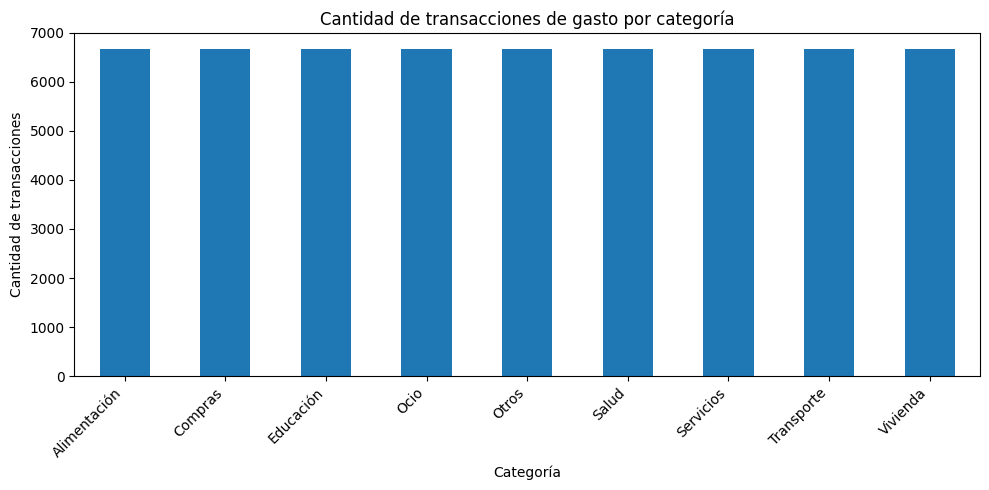

,cantidad
categoria,
Alimentación,6667
Compras,6666
Educación,6667
Ocio,6667
Otros,6666
Salud,6667
Servicios,6666
Transporte,6667
Vivienda,6667


In [86]:
conteo_gastos = (
    transacciones
    .loc[transacciones["tipo"] == "GASTO", "categoria"]
    .value_counts()
    .sort_index()
)

ax = conteo_gastos.plot(
    kind="bar",
    figsize=(10, 5),
    title="Cantidad de transacciones de gasto por categoría",
)

ax.set_xlabel("Categoría")
ax.set_ylabel("Cantidad de transacciones")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(
    conteo_gastos.rename("cantidad").to_frame()
)

**Interpretación:** Las categorías de gasto presentan una distribución balanceada, con la misma cantidad de transacciones en cada clase. Al tratarse de un dataset sintético, esta distribución fue definida de manera controlada para evitar que el desbalance de clases afecte el entrenamiento y la evaluación del modelo de clasificación de gastos. En un escenario con datos reales sería esperable encontrar una distribución más heterogénea, por lo que podrían requerirse técnicas como la ponderación de clases o estrategias de remuestreo.


### 6.2 Categoria Ingresos

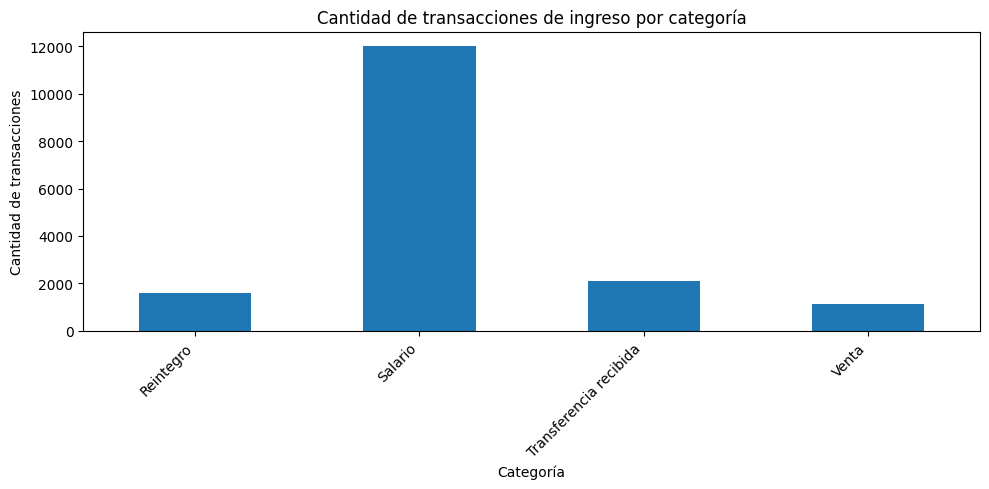

,cantidad
categoria,
Reintegro,1592
Salario,12000
Transferencia recibida,2104
Venta,1125


In [87]:
conteo_ingresos = (
    transacciones
    .loc[transacciones["tipo"] == "INGRESO", "categoria"]
    .value_counts()
    .sort_index()
)

ax = conteo_ingresos.plot(
    kind="bar",
    figsize=(10, 5),
    title="Cantidad de transacciones de ingreso por categoría",
)

ax.set_xlabel("Categoría")
ax.set_ylabel("Cantidad de transacciones")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(
    conteo_ingresos.rename("cantidad").to_frame()
)

**Interpretación**: La distribución de las categorías de ingreso refleja una mayor concentración en la categoría Salario, seguida por Transferencia recibida, Reintegro y Venta. Esta distribución fue definida de forma intencional durante la generación del dataset sintético para representar un escenario financiero más cercano al comportamiento esperado de un usuario promedio, donde el salario constituye la principal fuente de ingresos. Esta configuración proporciona un contexto adecuado para el análisis exploratorio y las etapas posteriores de Ingeniería de Atributos y Machine Learning.


## 7. Distribución de perfiles financieros
En esta sección se analiza la distribución de la variable objetivo perfil_financiero, asignada a cada usuario a partir de sus características financieras. Conocer la frecuencia de cada perfil permite identificar posibles desbalances entre clases, aspecto relevante para el entrenamiento y la evaluación de los modelos de clasificación.

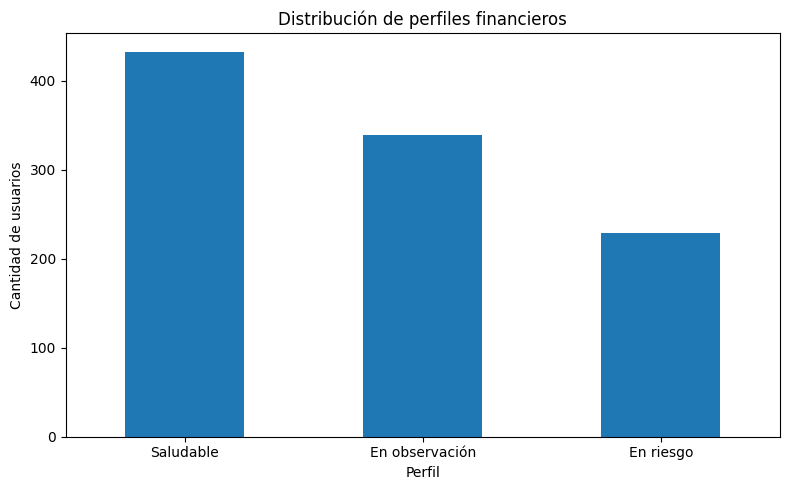

,cantidad
perfil_financiero,
Saludable,432
En observación,339
En riesgo,229


In [88]:
conteo_perfiles = usuarios["perfil_financiero"].value_counts()

ax = conteo_perfiles.plot(
    kind="bar",
    figsize=(8, 5),
    title="Distribución de perfiles financieros",
)
ax.set_xlabel("Perfil")
ax.set_ylabel("Cantidad de usuarios")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(conteo_perfiles.rename("cantidad").to_frame())

**Interpretación:** La distribución de los perfiles financieros presenta un desbalance moderado entre las tres clases. El perfil Saludable concentra la mayor cantidad de usuarios, seguido por En observación y En riesgo. Estos perfiles fueron asignados a partir de indicadores financieros derivados, como la relación entre ingresos y gastos, el nivel de endeudamiento y la capacidad de ahorro, con el objetivo de representar distintos niveles de salud financiera y proporcionar una variable objetivo consistente para el entrenamiento y la evaluación de los modelos de clasificación.

## 8. Análisis de montos y medios de pago

### 8.1 Gastos por categoría

,count,sum,mean,median,max
categoria,,,,,
Vivienda,6667,"7,066,347.5300","1,059.8991","1,003.9600","2,000.0000"
Compras,6666,"3,545,103.7700",531.8187,507.9650,"1,000.0000"
Educación,6667,"3,512,076.9300",526.7852,502.4000,"1,000.0000"
Salud,6667,"1,785,226.5200",267.7706,256.7000,500.0000
Otros,6666,"1,747,974.6100",262.2224,253.4600,500.0000
Servicios,6666,"1,422,348.4300",213.3736,203.8950,400.0000
Ocio,6667,"1,068,869.1400",160.3224,152.4200,300.0000
Alimentación,6667,"716,483.3300",107.4671,102.9000,200.0000
Transporte,6667,"644,683.5500",96.6977,92.4900,180.0000


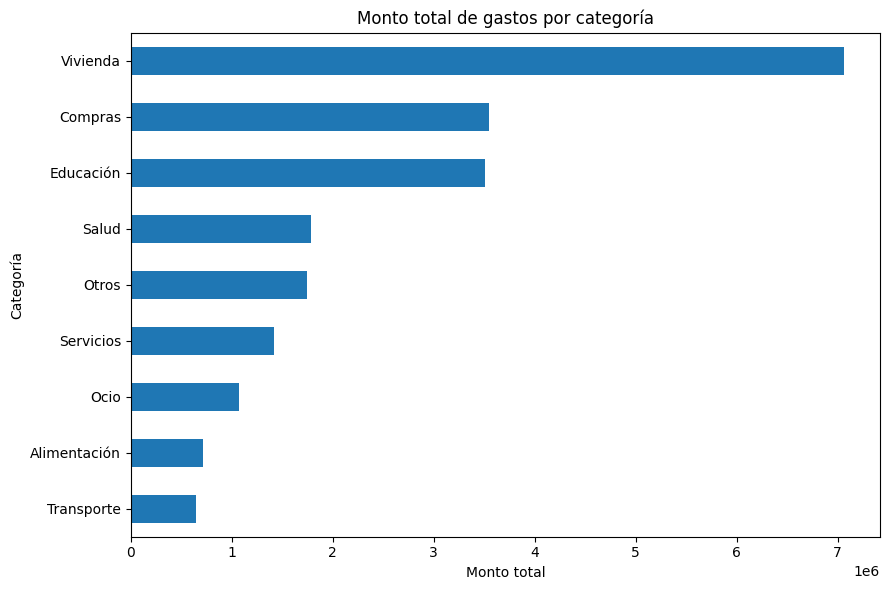

In [89]:
gastos = transacciones[
    transacciones["tipo"] == "GASTO"
]

resumen_gastos_categoria = (
    gastos.groupby("categoria")["monto"]
    .agg(["count", "sum", "mean", "median", "max"])
    .sort_values("sum", ascending=False)
)

display(resumen_gastos_categoria)

ax = resumen_gastos_categoria["sum"].sort_values().plot(
    kind="barh",
    figsize=(9, 6),
    title="Monto total de gastos por categoría",
)

ax.set_xlabel("Monto total")
ax.set_ylabel("Categoría")
plt.tight_layout()
plt.show()

**Interpretación:** El análisis del monto total por categoría permite identificar los principales destinos del gasto registrados en el conjunto de datos. Las estadísticas descriptivas (cantidad, suma, media, mediana y monto máximo) ofrecen una visión general del comportamiento de cada categoría y facilitan la comparación entre los distintos tipos de egresos.

### 8.2 Medios de pago utilizados en gastos

In [90]:
display(
    gastos["medio_pago"]
    .value_counts()
    .rename("cantidad")
    .to_frame()
)

,cantidad
medio_pago,
Pago con QR,8659
Tarjeta de crédito,8653
Efectivo,8621
Tarjeta de débito,8577
Billetera digital,8519
Transferencia bancaria,8509
Débito automático,8462


**Interpretación:** La distribución de los medios de pago muestra los diferentes mecanismos utilizados para realizar las transacciones de gasto. La presencia de múltiples medios de pago aporta mayor diversidad al conjunto de datos y permite representar distintos hábitos de consumo en el análisis exploratorio.

### 8.3 Ingresos por categoría

,count,sum,mean,median,max
categoria,,,,,
Salario,12000,"49,127,241.6600","4,093.9368","4,096.1900","7,201.9100"
Transferencia recibida,2104,"1,550,359.8200",736.8630,748.0000,"1,498.7700"
Venta,1125,"1,449,104.7200","1,288.0931","1,294.8500","2,499.4900"
Reintegro,1592,"397,941.8300",249.9635,242.1500,498.8300


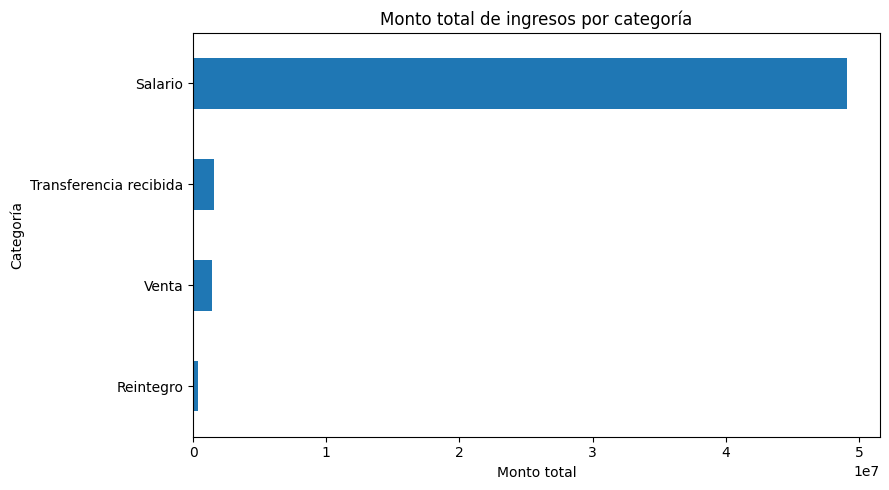

In [91]:
ingresos = transacciones[
    transacciones["tipo"] == "INGRESO"
]

resumen_ingresos_categoria = (
    ingresos.groupby("categoria")["monto"]
    .agg(["count", "sum", "mean", "median", "max"])
    .sort_values("sum", ascending=False)
)

display(resumen_ingresos_categoria)

ax = resumen_ingresos_categoria["sum"].sort_values().plot(
    kind="barh",
    figsize=(9, 5),
    title="Monto total de ingresos por categoría",
)

ax.set_xlabel("Monto total")
ax.set_ylabel("Categoría")
plt.tight_layout()
plt.show()

**Interpretación:** El análisis de los ingresos por categoría evidencia que la principal fuente de ingresos corresponde a los salarios, complementada por categorías como transferencias recibidas, reintegros y ventas. Esta distribución busca representar un escenario financiero sintético cercano al comportamiento esperado de un usuario promedio.

### 8.4 Medios de acreditación de ingresos

In [92]:
display(
    ingresos["medio_pago"]
    .value_counts()
    .rename("cantidad")
    .to_frame()
)

,cantidad
medio_pago,
Billetera digital,3427
Efectivo,3380
Acreditación automática,3356
Depósito en cuenta,3329
Transferencia bancaria,3329


**Interpretación:** La distribución de los medios de acreditación presenta una utilización relativamente equilibrada entre los distintos canales disponibles para recibir ingresos. Esta configuración contribuye a representar diversas formas de acreditación y aporta mayor variedad al conjunto de datos sintético.

## 9. Relación entre variables financieras

En esta sección se analiza la correlación lineal entre las principales variables financieras de los usuarios mediante una matriz de correlación. Este análisis permite identificar asociaciones positivas o negativas entre los indicadores económicos y comprender cómo se relacionan entre sí antes de la etapa de Ingeniería de Atributos y entrenamiento de modelos.

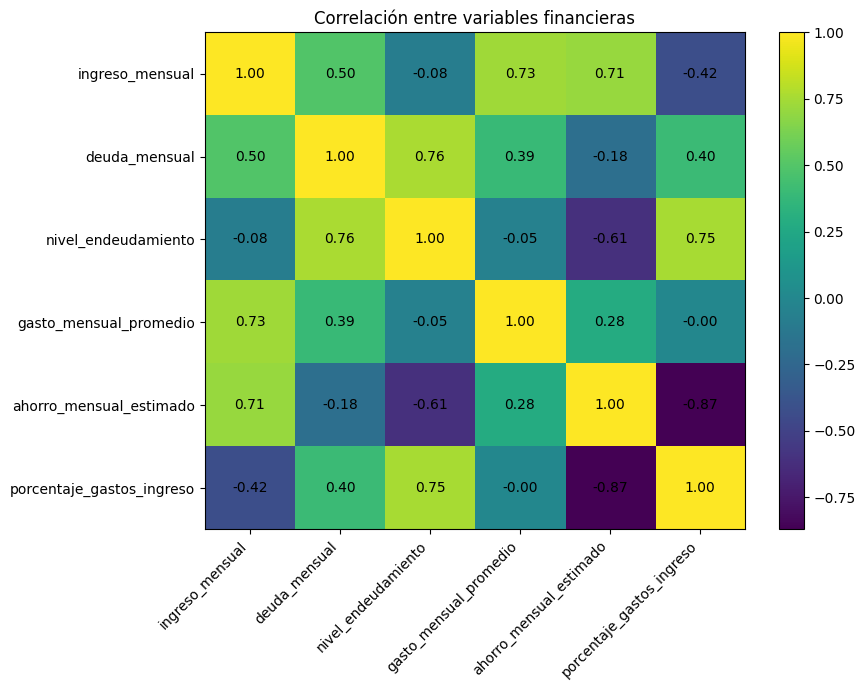

In [93]:
variables_correlacion = [
    "ingreso_mensual",
    "deuda_mensual",
    "nivel_endeudamiento",
    "gasto_mensual_promedio",
    "ahorro_mensual_estimado",
    "porcentaje_gastos_ingreso",
]

correlaciones = usuarios[variables_correlacion].corr()

fig, ax = plt.subplots(figsize=(9, 7))
imagen = ax.imshow(correlaciones, aspect="auto")
ax.set_xticks(range(len(correlaciones.columns)))
ax.set_yticks(range(len(correlaciones.index)))
ax.set_xticklabels(correlaciones.columns, rotation=45, ha="right")
ax.set_yticklabels(correlaciones.index)

for fila in range(len(correlaciones.index)):
    for columna in range(len(correlaciones.columns)):
        ax.text(
            columna,
            fila,
            f"{correlaciones.iloc[fila, columna]:.2f}",
            ha="center",
            va="center",
        )

ax.set_title("Correlación entre variables financieras")
fig.colorbar(imagen, ax=ax)
plt.tight_layout()
plt.show()

**Interpretación:**

La matriz de correlación permite identificar el grado de asociación lineal entre las variables financieras del conjunto de datos. Se espera observar relaciones consistentes entre indicadores derivados, como el ingreso mensual, el gasto mensual promedio, el ahorro mensual estimado y el porcentaje de gastos sobre ingresos, ya que estos fueron calculados a partir de la información financiera de cada usuario. Este análisis resulta útil para comprender la estructura del conjunto de datos y detectar posibles relaciones relevantes antes de la construcción de los modelos de Machine Learning.

# 10. Procesamiento financiero, textual e ingeniería de atributos

En esta etapa se generan y preparan variables derivadas a partir de la información financiera y textual disponible en el conjunto de datos. Se incorporan atributos temporales, monetarios y de procesamiento de texto con el objetivo de enriquecer la representación de los datos y proporcionar características más informativas para las etapas posteriores de clasificación, análisis del perfil financiero y entrenamiento de los modelos de Machine Learning.

In [94]:
def crear_features_transacciones(df: pd.DataFrame) -> pd.DataFrame:
    resultado = df.copy()

    # ==========================
    # Variables temporales
    # ==========================
    resultado["anio"] = resultado["fecha"].dt.year
    resultado["mes"] = resultado["fecha"].dt.month
    resultado["trimestre"] = resultado["fecha"].dt.quarter
    resultado["dia_semana"] = resultado["fecha"].dt.dayofweek
    resultado["es_fin_de_semana"] = (
        resultado["dia_semana"].isin([5, 6]).astype(int)
    )

    # ==========================
    # Variables monetarias
    # ==========================
    resultado["monto_log"] = np.log1p(resultado["monto"])

    mediana_monto_usuario = (
        resultado.groupby("usuario_id")["monto"]
        .transform("median")
    )

    resultado["es_transaccion_grande"] = (
        resultado["monto"] > (2 * mediana_monto_usuario)
    ).astype(int)

    # ==========================
    # Variables textuales
    # ==========================
    resultado["longitud_descripcion"] = (
        resultado["descripcion_limpia"].str.len()
    )

    resultado["cantidad_palabras"] = (
        resultado["descripcion_limpia"].str.split().str.len()
    )

    # ==========================
    # Variables binarias
    # ==========================
    resultado["recurrente_binario"] = (
        resultado["recurrente"]
        .str.lower()
        .map({"sí": 1, "si": 1, "no": 0})
        .fillna(0)
        .astype(int)
    )

    return resultado


transacciones_features = crear_features_transacciones(transacciones)

columnas_features_creadas = [
    "descripcion_limpia",
    "anio",
    "mes",
    "trimestre",
    "dia_semana",
    "es_fin_de_semana",
    "monto_log",
    "longitud_descripcion",
    "cantidad_palabras",
    "recurrente_binario",
    "es_transaccion_grande",
]

display(transacciones_features[columnas_features_creadas].head())

,descripcion_limpia,anio,mes,trimestre,dia_semana,es_fin_de_semana,monto_log,longitud_descripcion,cantidad_palabras,recurrente_binario,es_transaccion_grande
0,cena,2025,12,4,0,0,5.0965,4,1,1,0
1,materiales de construccion,2025,10,4,4,0,4.1553,26,3,0,0
2,certificacion profesional,2025,9,3,3,0,5.5930,25,2,0,0
3,concierto,2026,1,1,5,1,4.9861,9,1,0,0
4,agua,2026,2,1,2,0,5.9940,4,1,1,0


**Interpretación:** Se incorporaron nuevas variables derivadas que amplían la información disponible en el conjunto de datos. Entre ellas se incluyen atributos temporales (año, mes, trimestre, día de la semana y fin de semana), transformaciones monetarias (monto en escala logarítmica), características textuales (longitud de la descripción y cantidad de palabras) e indicadores binarios, como la recurrencia de la transacción y la identificación de operaciones de monto significativamente superior a la mediana del usuario. Estas variables constituyen la base para las etapas posteriores de modelado y análisis predictivo.

## 11. Variables agregadas por usuario
En esta sección se consolidan las transacciones a nivel de usuario mediante la generación de variables agregadas. Se calculan métricas descriptivas sobre la actividad financiera, como la cantidad de transacciones, estadísticas de los montos y características relacionadas con la recurrencia y diversidad de categorías. Además, se incorporan indicadores financieros derivados que representan la relación entre ingresos, gastos, deuda y ahorro, los cuales servirán como variables de entrada para los modelos de Machine Learning.

In [95]:
resumen_transacciones_usuario = (
    transacciones_features
    .groupby("usuario_id")
    .agg(
        cantidad_transacciones=("transaction_id", "count"),
        monto_total=("monto", "sum"),
        monto_promedio_transaccion=("monto", "mean"),
        monto_mediano=("monto", "median"),
        monto_maximo=("monto", "max"),
        desviacion_montos=("monto", "std"),
        cantidad_recurrentes=("recurrente_binario", "sum"),
        cantidad_transacciones_grandes=("es_transaccion_grande", "sum"),
        categorias_distintas=("categoria", "nunique"),
    )
    .reset_index()
)

dataset_perfiles = usuarios.merge(
    resumen_transacciones_usuario,
    on="usuario_id",
    how="left",
    validate="one_to_one",
)

dataset_perfiles["ratio_deuda_ingreso_calculado"] = np.where(
    dataset_perfiles["ingreso_mensual"] > 0,
    dataset_perfiles["deuda_mensual"] / dataset_perfiles["ingreso_mensual"],
    0,
)

dataset_perfiles["ratio_gasto_ingreso_calculado"] = np.where(
    dataset_perfiles["ingreso_mensual"] > 0,
    dataset_perfiles["gasto_mensual_promedio"]
    / dataset_perfiles["ingreso_mensual"],
    0,
)

dataset_perfiles["ratio_ahorro_ingreso_calculado"] = np.where(
    dataset_perfiles["ingreso_mensual"] > 0,
    dataset_perfiles["ahorro_mensual_estimado"]
    / dataset_perfiles["ingreso_mensual"],
    0,
)

display(dataset_perfiles.head())

,usuario_id,ingreso_mensual,deuda_mensual,nivel_endeudamiento,gasto_mensual_promedio,ahorro_mensual_estimado,porcentaje_gastos_ingreso,frecuencia_ahorro,perfil_financiero,cantidad_transacciones,monto_total,monto_promedio_transaccion,monto_mediano,monto_maximo,desviacion_montos,cantidad_recurrentes,cantidad_transacciones_grandes,categorias_distintas,ratio_deuda_ingreso_calculado,ratio_gasto_ingreso_calculado,ratio_ahorro_ingreso_calculado
0,USR0001,"4,625.5000",832.9000,19.0200,"1,809.4400","1,983.1600",57.1300,Alta,Saludable,72,"77,219.3300","1,072.4907",353.4300,"4,481.1400","1,541.6721",26,23,11,0.1801,0.3912,0.4287
1,USR0002,"6,560.3200",968.0900,15.8700,"2,153.6500","3,438.5800",47.5900,Alta,Saludable,73,"104,567.6400","1,432.4334",500.0000,"6,238.5700","2,107.6403",27,17,13,0.1476,0.3283,0.5241
2,USR0003,"4,235.9000",786.6600,18.9100,"3,720.4000",-271.1600,106.4000,Nunca,En riesgo,96,"95,475.5900",994.5374,394.4900,"4,268.0300","1,318.7075",33,32,12,0.1857,0.8783,-0.0640
3,USR0004,"4,209.9900","1,933.4400",53.5600,"1,535.1200",741.4300,82.3900,Media,En riesgo,65,"68,941.3800","1,060.6366",385.0900,"3,700.2400","1,317.4979",27,21,12,0.4593,0.3646,0.1761
4,USR0005,"2,138.3400",440.6800,24.4600,"1,592.6100",105.0500,95.0900,Baja,En riesgo,92,"44,771.3600",486.6452,249.4650,"1,837.9000",562.8268,32,26,12,0.2061,0.7448,0.0491


**Interpretación:** Se construyó un conjunto de datos consolidado a nivel de usuario que combina la información financiera original con las variables agregadas obtenidas a partir de las transacciones. Este proceso permite representar el comportamiento financiero de cada usuario mediante atributos numéricos más informativos, facilitando las etapas posteriores de entrenamiento, evaluación y predicción de los modelos de clasificación.

## 12. Exportación de datasets procesados

Una vez finalizado el proceso de limpieza, transformación e ingeniería de atributos, se exportan los conjuntos de datos procesados para su utilización en las etapas posteriores del proyecto. Se generan dos archivos: uno correspondiente a las transacciones enriquecidas con nuevas características y otro que contiene el conjunto de datos consolidado a nivel de usuario, el cual será utilizado para el entrenamiento y evaluación de los modelos de Machine Learning.

In [96]:
RUTA_TRANSACCIONES_PROCESADAS = (
    PROCESSED_DIR / "transacciones_features.csv"
)
RUTA_PERFILES_PROCESADOS = (
    PROCESSED_DIR / "usuarios_features.csv"
)

transacciones_features.to_csv(
    RUTA_TRANSACCIONES_PROCESADAS,
    index=False,
)
dataset_perfiles.to_csv(
    RUTA_PERFILES_PROCESADOS,
    index=False,
)

print(RUTA_TRANSACCIONES_PROCESADAS)
print(RUTA_PERFILES_PROCESADOS)

artefactos_financeai_v3/datos_procesados/transacciones_features.csv
artefactos_financeai_v3/datos_procesados/usuarios_features.csv


**Resultado:** Los conjuntos de datos procesados fueron exportados correctamente al directorio correspondiente. Estos archivos constituyen la entrada para las etapas de clasificación de gastos, análisis del perfil financiero y entrenamiento de los modelos de Machine Learning, permitiendo reutilizar la información procesada sin necesidad de repetir las etapas previas del pipeline.

# 13. Modelo de clasificación de gastos

En esta etapa se desarrolla un modelo supervisado para predecir la categoría de cada transacción de gasto a partir de su descripción y de otras características asociadas.

El pipeline combina:

- **TF-IDF**, para representar numéricamente el contenido textual de la descripción.
- **Variables numéricas**, como el monto y los atributos derivados de la transacción.
- **Codificación One-Hot**, para procesar variables categóricas como el medio de pago y la recurrencia.
- **Regresión logística multiclase**, utilizada como algoritmo de clasificación.

Para evaluar el rendimiento del modelo se aplican dos estrategias:

1. **Hold-out estratificado por transacción:** conserva la proporción de las categorías entre entrenamiento y prueba. Esta evaluación permite medir el desempeño sobre transacciones similares a las observadas durante el entrenamiento.

2. **Validación agrupada por descripción:** evita que una misma descripción aparezca simultáneamente en los conjuntos de entrenamiento y validación. Esta estrategia representa un escenario más exigente y permite estimar mejor la capacidad de generalización del modelo frente a descripciones no vistas.

In [97]:
# Se utilizan únicamente transacciones de gasto
gastos_modelo = transacciones_features[
    transacciones_features["tipo"] == "GASTO"
].copy()

features_categoria = [
    "descripcion_limpia",
    "monto",
    "mes",
    "dia_semana",
    "es_fin_de_semana",
    "longitud_descripcion",
    "cantidad_palabras",
    "medio_pago",
    "recurrente",
]

target_categoria = "categoria"

X_categoria = gastos_modelo[features_categoria].copy()
y_categoria = gastos_modelo[target_categoria].copy()


preprocesador_categoria = ColumnTransformer(
    transformers=[
        (
            "texto",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=5000,
                sublinear_tf=True,
            ),
            "descripcion_limpia",
        ),
        (
            "numericas",
            Pipeline([
                (
                    "imputacion",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "escalado",
                    StandardScaler(),
                ),
            ]),
            [
                "monto",
                "mes",
                "dia_semana",
                "es_fin_de_semana",
                "longitud_descripcion",
                "cantidad_palabras",
            ],
        ),
        (
            "categoricas",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
            [
                "medio_pago",
                "recurrente",
            ],
        ),
    ]
)


modelo_categoria = Pipeline([
    (
        "preprocesamiento",
        preprocesador_categoria,
    ),
    (
        "clasificador",
        LogisticRegression(
            max_iter=2500,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
])
print(f"Cantidad de gastos utilizados: {len(X_categoria)}")
print(f"Cantidad de categorías: {y_categoria.nunique()}")

display(
    y_categoria
    .value_counts()
    .rename("cantidad")
    .to_frame()
)

Cantidad de gastos utilizados: 60000
Cantidad de categorías: 9


,cantidad
categoria,
Alimentación,6667
Vivienda,6667
Educación,6667
Ocio,6667
Transporte,6667
Salud,6667
Servicios,6666
Otros,6666
Compras,6666


**Interpretación:** Se construyó un pipeline de clasificación que integra información textual, numérica y categórica de las transacciones de gasto. Las descripciones se transforman mediante TF-IDF, las variables numéricas son imputadas y estandarizadas, y las variables categóricas se codifican mediante One-Hot Encoding. Finalmente, se utiliza una regresión logística multiclase con ponderación balanceada para predecir la categoría correspondiente a cada gasto.

## 14. Evaluación mediante hold-out estratificado

Como primera evaluación, el conjunto de datos se divide en entrenamiento y prueba mediante un esquema hold-out estratificado. Esta estrategia conserva la proporción de las distintas categorías de gasto en ambos subconjuntos, permitiendo estimar el desempeño del modelo sobre transacciones con una distribución similar a la observada durante el entrenamiento.

Se reportan las métricas de Accuracy, F1 Macro y F1 Weighted, junto con el informe de clasificación y la matriz de confusión para analizar el comportamiento del modelo en cada categoría.

In [98]:
X_cat_train, X_cat_test, y_cat_train, y_cat_test = train_test_split(
    X_categoria,
    y_categoria,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_categoria,
)

modelo_categoria.fit(X_cat_train, y_cat_train)
pred_categoria = modelo_categoria.predict(X_cat_test)

metricas_categoria_holdout = {
    "accuracy": accuracy_score(y_cat_test, pred_categoria),
    "f1_macro": f1_score(y_cat_test, pred_categoria, average="macro"),
    "f1_weighted": f1_score(
        y_cat_test,
        pred_categoria,
        average="weighted",
    ),
}

display(
    pd.Series(
        metricas_categoria_holdout,
        name="clasificacion_gastos_holdout",
    ).round(4)
)

print(classification_report(
    y_cat_test,
    pred_categoria,
    zero_division=0,
))

,clasificacion_gastos_holdout
accuracy,1.0000
f1_macro,1.0000
f1_weighted,1.0000


              precision    recall  f1-score   support

Alimentación       1.00      1.00      1.00      1333
     Compras       1.00      1.00      1.00      1333
   Educación       1.00      1.00      1.00      1333
        Ocio       1.00      1.00      1.00      1334
       Otros       1.00      1.00      1.00      1333
       Salud       1.00      1.00      1.00      1334
   Servicios       1.00      1.00      1.00      1333
  Transporte       1.00      1.00      1.00      1334
    Vivienda       1.00      1.00      1.00      1333

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000



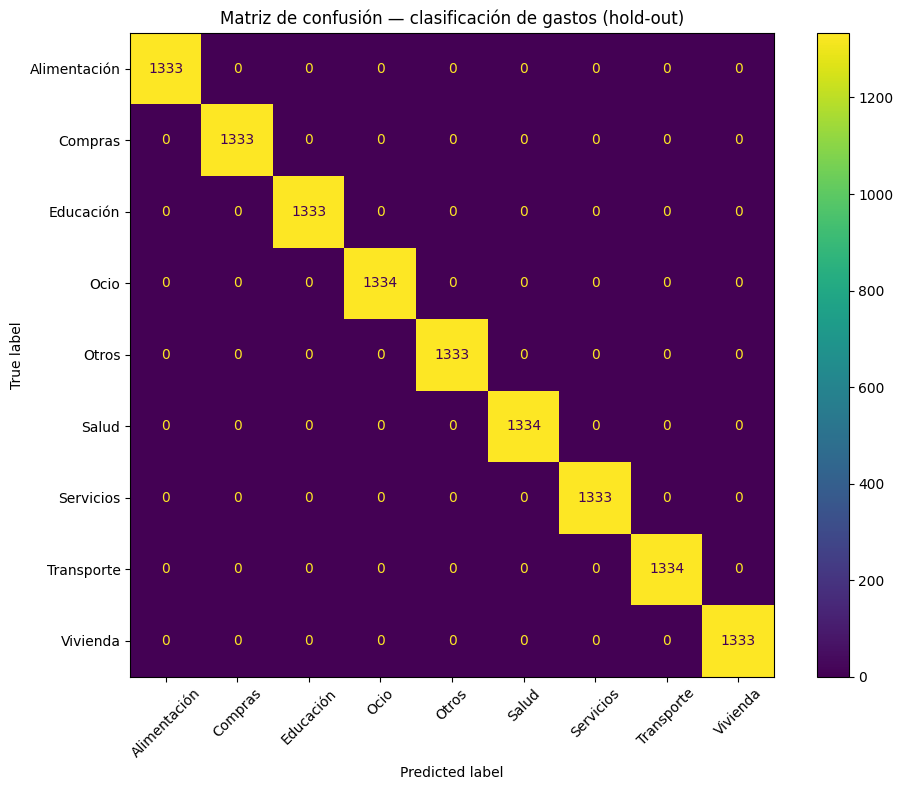

In [99]:
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_cat_test,
    pred_categoria,
    xticks_rotation=45,
    ax=ax,
)
ax.set_title(
    "Matriz de confusión — clasificación de gastos (hold-out)"
)
plt.tight_layout()
plt.show()

### Interpretación del resultado perfecto
La evaluación mediante una partición aleatoria puede producir métricas muy elevadas, e incluso cercanas al rendimiento perfecto, debido a que el dataset sintético utiliza un vocabulario controlado. En este escenario, una misma descripción puede aparecer tanto en el conjunto de entrenamiento como en el de prueba, manteniendo una asociación prácticamente unívoca con su categoría correspondiente.

En consecuencia, esta evaluación verifica que el pipeline clasifique correctamente nuevas transacciones pertenecientes a descripciones ya conocidas. Sin embargo, por sí sola no permite medir la capacidad de generalización del modelo frente a descripciones no observadas durante el entrenamiento. Por este motivo, en la siguiente sección se aplica una validación agrupada por descripción, que constituye un escenario de evaluación más exigente y representativo.

## 15. Evaluación robusta agrupada por descripción

Como segunda estrategia de evaluación, se aplica una validación cruzada utilizando **StratifiedGroupKFold**, donde cada descripción de transacción pertenece exclusivamente al conjunto de entrenamiento o al de validación.

A diferencia de la partición hold-out tradicional, este enfoque impide que una misma descripción aparezca en ambos conjuntos, evitando el aprendizaje basado en textos idénticos y proporcionando una estimación más realista de la capacidad de generalización del modelo.

Se reportan las métricas promedio obtenidas en los distintos pliegues, junto con el informe de clasificación y la matriz de confusión de uno de ellos.

In [100]:
# Cada descripción funciona como grupo de validación
grupos_descripcion = X_categoria["descripcion_limpia"].copy()

cv_agrupada = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

resultados_cv_categoria = cross_validate(
    estimator=modelo_categoria,
    X=X_categoria,
    y=y_categoria,
    groups=grupos_descripcion,
    cv=cv_agrupada,
    scoring={
        "accuracy": "accuracy",
        "f1_macro": "f1_macro",
        "f1_weighted": "f1_weighted",
    },
    return_train_score=False,
    n_jobs=None,
)

resumen_cv_categoria = pd.DataFrame({
    "metrica": [
        "accuracy",
        "f1_macro",
        "f1_weighted",
    ],
    "promedio": [
        resultados_cv_categoria["test_accuracy"].mean(),
        resultados_cv_categoria["test_f1_macro"].mean(),
        resultados_cv_categoria["test_f1_weighted"].mean(),
    ],
    "desvio_estandar": [
        resultados_cv_categoria["test_accuracy"].std(),
        resultados_cv_categoria["test_f1_macro"].std(),
        resultados_cv_categoria["test_f1_weighted"].std(),
    ],
})

display(resumen_cv_categoria.round(4))

,metrica,promedio,desvio_estandar
0,accuracy,0.3618,0.0307
1,f1_macro,0.2739,0.0490
2,f1_weighted,0.3324,0.0582


In [101]:
indices_train_group, indices_test_group = next(
    cv_agrupada.split(
        X=X_categoria,
        y=y_categoria,
        groups=grupos_descripcion,
    )
)

X_cat_group_train = X_categoria.iloc[
    indices_train_group
].copy()

X_cat_group_test = X_categoria.iloc[
    indices_test_group
].copy()

y_cat_group_train = y_categoria.iloc[
    indices_train_group
].copy()

y_cat_group_test = y_categoria.iloc[
    indices_test_group
].copy()


modelo_categoria_agrupado = Pipeline([
    (
        "preprocesamiento",
        preprocesador_categoria,
    ),
    (
        "clasificador",
        LogisticRegression(
            max_iter=2500,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
])


modelo_categoria_agrupado.fit(
    X_cat_group_train,
    y_cat_group_train,
)

pred_categoria_agrupada = (
    modelo_categoria_agrupado.predict(
        X_cat_group_test
    )
)


descripciones_train = set(
    X_cat_group_train["descripcion_limpia"]
)

descripciones_test = set(
    X_cat_group_test["descripcion_limpia"]
)

descripciones_compartidas = (
    descripciones_train & descripciones_test
)


print(
    "Cantidad de transacciones de entrenamiento:",
    len(X_cat_group_train),
)

print(
    "Cantidad de transacciones de prueba:",
    len(X_cat_group_test),
)

print(
    "Descripciones únicas en entrenamiento:",
    len(descripciones_train),
)

print(
    "Descripciones únicas en prueba:",
    len(descripciones_test),
)

print(
    "Descripciones compartidas entre entrenamiento y prueba:",
    len(descripciones_compartidas),
)


metricas_categoria_agrupada = {
    "accuracy": accuracy_score(
        y_cat_group_test,
        pred_categoria_agrupada,
    ),
    "f1_macro": f1_score(
        y_cat_group_test,
        pred_categoria_agrupada,
        average="macro",
    ),
    "f1_weighted": f1_score(
        y_cat_group_test,
        pred_categoria_agrupada,
        average="weighted",
    ),
}

display(
    pd.Series(
        metricas_categoria_agrupada,
        name="clasificacion_gastos_agrupada",
    ).round(4)
)


print(
    classification_report(
        y_cat_group_test,
        pred_categoria_agrupada,
        zero_division=0,
    )
)

Cantidad de transacciones de entrenamiento: 48005
Cantidad de transacciones de prueba: 11995
Descripciones únicas en entrenamiento: 72
Descripciones únicas en prueba: 18
Descripciones compartidas entre entrenamiento y prueba: 0


,clasificacion_gastos_agrupada
accuracy,0.3785
f1_macro,0.3586
f1_weighted,0.2762


              precision    recall  f1-score   support

Alimentación       0.56      0.55      0.56      1266
     Compras       0.34      0.80      0.48       653
   Educación       0.36      1.00      0.53      1321
        Ocio       0.00      0.00      0.00      2066
       Otros       0.07      0.01      0.01      2013
       Salud       0.26      0.25      0.25      1984
   Servicios       0.44      1.00      0.61       683
  Transporte       0.43      1.00      0.60       678
    Vivienda       1.00      0.11      0.19      1331

    accuracy                           0.38     11995
   macro avg       0.38      0.52      0.36     11995
weighted avg       0.33      0.38      0.28     11995



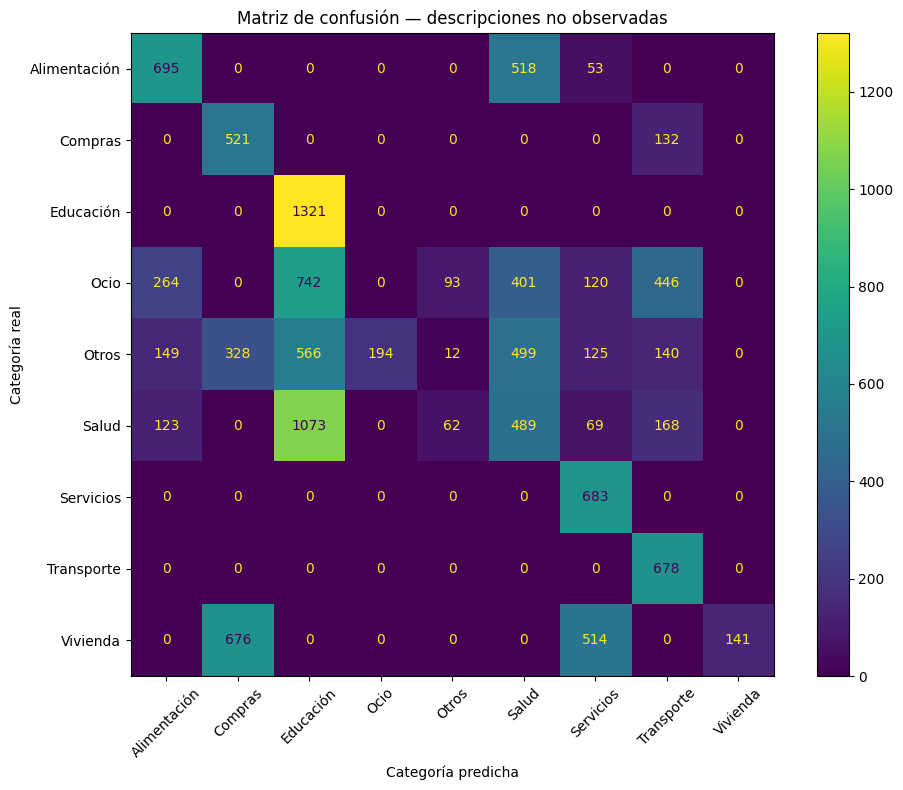

In [102]:
fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_cat_group_test,
    pred_categoria_agrupada,
    xticks_rotation=45,
    ax=ax,
)

ax.set_title(
    "Matriz de confusión — descripciones no observadas"
)

ax.set_xlabel("Categoría predicha")
ax.set_ylabel("Categoría real")

plt.tight_layout()
plt.show()

### Interpretación del resultado

La validación cruzada agrupada obtuvo un accuracy promedio de **0.3618**, con un F1 Macro de **0.2739** y un F1 Weighted de **0.3324**. La dispersión entre los pliegues es relativamente baja, lo que indica que el rendimiento se mantiene de forma bastante estable entre las distintas particiones.

En el pliegue analizado en detalle, el modelo alcanzó un accuracy de **0.3785**. Además, se comprobó que no existen descripciones compartidas entre entrenamiento y prueba, por lo que la evaluación evita la fuga de información asociada a textos repetidos.

El desempeño varía considerablemente según la categoría. Las categorías **Educación**, **Servicios** y **Transporte** presentan un recall de 1.00, lo que indica que todas las transacciones reales de esas clases fueron detectadas. Sin embargo, algunas de estas predicciones presentan menor precisión, lo que significa que el modelo también asigna incorrectamente otras transacciones a dichas categorías.

Las mayores dificultades se observan en **Ocio**, **Otros**, **Salud** y **Vivienda**. En particular, Ocio no presenta aciertos en el pliegue evaluado, mientras que Vivienda obtiene una precisión alta pero un recall bajo, detectando correctamente solo una parte reducida de sus transacciones.

La matriz de confusión muestra que varias categorías son confundidas con Educación, Salud, Servicios y Transporte. Esto sugiere que, cuando las descripciones no fueron observadas previamente, las variables actuales no siempre contienen información suficiente para distinguir correctamente conceptos financieros similares.

En conclusión, el modelo funciona muy bien sobre conceptos conocidos, pero su capacidad de generalización frente a descripciones nuevas es limitada. Estos resultados evidencian la necesidad de incorporar una mayor variedad de descripciones, enriquecer las características textuales y evaluar modelos capaces de representar mejor el significado semántico de las transacciones.

## 16. Interpretabilidad del clasificador de gastos

Con el objetivo de comprender el funcionamiento interno del modelo, se analizan las variables con mayor influencia positiva en la predicción de cada categoría de gasto.

Dado que el clasificador utilizado es una Regresión Logística, es posible inspeccionar directamente sus coeficientes y determinar cuáles son los términos y características que más contribuyen a identificar cada categoría. Este análisis aporta transparencia al modelo y facilita la validación de que las decisiones se basan en patrones coherentes del conjunto de datos.

In [103]:
modelo_categoria.fit(
    X_categoria,
    y_categoria,
)

preprocesador_entrenado = modelo_categoria.named_steps[
    "preprocesamiento"
]

clasificador_entrenado = modelo_categoria.named_steps[
    "clasificador"
]

nombres_features = (
    preprocesador_entrenado.get_feature_names_out()
)

coeficientes = clasificador_entrenado.coef_
clases_categoria = clasificador_entrenado.classes_

TOP_FEATURES = 8

filas_terminos = []

for indice_clase, clase in enumerate(clases_categoria):

    mejores_indices = np.argsort(
        coeficientes[indice_clase]
    )[-TOP_FEATURES:][::-1]

    for posicion, indice_feature in enumerate(
        mejores_indices,
        start=1,
    ):
        filas_terminos.append({
            "categoria": clase,
            "posicion": posicion,
            "feature": (
                nombres_features[indice_feature]
                .replace("texto__", "")
            ),
            "coeficiente": coeficientes[
                indice_clase,
                indice_feature,
            ],
        })

terminos_importantes = (
    pd.DataFrame(filas_terminos)
    .sort_values(
        ["categoria", "posicion"]
    )
    .reset_index(drop=True)
)

display(
    terminos_importantes.round({
        "coeficiente": 4,
    })
)

,categoria,posicion,feature,coeficiente
0,Alimentación,1,restaurante,4.9995
1,Alimentación,2,carniceria,4.9347
2,Alimentación,3,de alimentos,4.9324
3,Alimentación,4,alimentos,4.9324
4,Alimentación,5,verduleria,4.9167
...,...,...,...,...
67,Vivienda,4,de muebles,4.5461
68,Vivienda,5,muebles,4.5461
69,Vivienda,6,limpieza,4.1635
70,Vivienda,7,de limpieza,4.1635


### Interpretación del resultado

El análisis de los coeficientes muestra que el modelo aprendió asociaciones coherentes entre las descripciones de las transacciones y sus respectivas categorías de gasto. Los términos con mayor peso positivo corresponden a palabras representativas de cada categoría, indicando que el clasificador identifica correctamente el vocabulario característico utilizado durante el entrenamiento.

Por ejemplo, en la categoría **Alimentación** destacan términos como *verdulería*, *restaurante*, *almuerzo*, *panadería* y *carnicería*, mientras que en **Vivienda** aparecen palabras relacionadas con el hogar, como *muebles*, *hogar* y *reparación*. Este comportamiento evidencia que la representación TF-IDF logra capturar información semántica relevante para la clasificación.

La inspección de los coeficientes constituye una herramienta de interpretabilidad que permite comprender el proceso de decisión del modelo y verificar que las predicciones se sustentan en patrones consistentes con el dominio financiero, facilitando además la detección de posibles asociaciones inesperadas o sesgos durante el entrenamiento.

# 17. Modelo de clasificación del perfil financiero

El objetivo de esta etapa es desarrollar un modelo supervisado capaz de clasificar a cada usuario en uno de los siguientes perfiles financieros:

- **Saludable**
- **En observación**
- **En riesgo**

El modelo utiliza variables financieras declaradas por el usuario, como ingresos, deuda, gastos y ahorro, junto con atributos agregados derivados de su comportamiento transaccional.

Para el procesamiento de los datos se aplican técnicas de imputación y estandarización sobre las variables numéricas, mientras que las variables categóricas son transformadas mediante codificación One-Hot. Finalmente, se emplea una Regresión Logística multiclase con ponderación balanceada.

In [104]:
features_perfil_numericas = [
    "ingreso_mensual",
    "deuda_mensual",
    "nivel_endeudamiento",
    "gasto_mensual_promedio",
    "ahorro_mensual_estimado",
    "porcentaje_gastos_ingreso",
    "cantidad_transacciones",
    "monto_total",
    "monto_promedio_transaccion",
    "monto_mediano",
    "monto_maximo",
    "desviacion_montos",
    "cantidad_recurrentes",
    "cantidad_transacciones_grandes",
    "categorias_distintas",
    "ratio_deuda_ingreso_calculado",
    "ratio_gasto_ingreso_calculado",
    "ratio_ahorro_ingreso_calculado",
]

features_perfil_categoricas = [
    "frecuencia_ahorro",
]

features_perfil = (
    features_perfil_numericas
    + features_perfil_categoricas
)

target_perfil = "perfil_financiero"

X_perfil = dataset_perfiles[
    features_perfil
].copy()

y_perfil = dataset_perfiles[
    target_perfil
].copy()


preprocesador_perfil = ColumnTransformer(
    transformers=[
        (
            "numericas",
            Pipeline([
                (
                    "imputacion",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "escalado",
                    StandardScaler(),
                ),
            ]),
            features_perfil_numericas,
        ),
        (
            "categoricas",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
            features_perfil_categoricas,
        ),
    ]
)


modelo_perfil = Pipeline([
    (
        "preprocesamiento",
        preprocesador_perfil,
    ),
    (
        "clasificador",
        LogisticRegression(
            max_iter=2500,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
])

### Preparación del modelo

Se construyó un pipeline que integra variables financieras originales y atributos agregados a nivel de usuario. Las variables numéricas son imputadas mediante la mediana y posteriormente estandarizadas, mientras que la frecuencia de ahorro se transforma mediante codificación One-Hot.

La Regresión Logística utiliza ponderación balanceada para reducir el efecto del desbalance existente entre los perfiles financieros. El pipeline resultante permite aplicar las mismas transformaciones durante el entrenamiento y en futuras predicciones, evitando inconsistencias entre ambas etapas.

## 18. Evaluación mediante hold-out estratificado

El modelo de clasificación del perfil financiero se evalúa mediante una partición hold-out estratificada, utilizando el 75 % de los usuarios para entrenamiento y el 25 % restante para prueba.

La estratificación permite conservar la proporción de los perfiles financieros en ambos subconjuntos. Para medir el rendimiento se utilizan Accuracy, F1 Macro y F1 Weighted, junto con el informe de clasificación y la matriz de confusión.

In [105]:
X_perfil_train, X_perfil_test, y_perfil_train, y_perfil_test = (
    train_test_split(
        X_perfil,
        y_perfil,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y_perfil,
    )
)

print(
    "Usuarios de entrenamiento:",
    len(X_perfil_train),
)

print(
    "Usuarios de prueba:",
    len(X_perfil_test),
)

modelo_perfil.fit(
    X_perfil_train,
    y_perfil_train,
)

pred_perfil = modelo_perfil.predict(
    X_perfil_test
)

metricas_perfil_holdout = {
    "accuracy": accuracy_score(
        y_perfil_test,
        pred_perfil,
    ),
    "f1_macro": f1_score(
        y_perfil_test,
        pred_perfil,
        average="macro",
    ),
    "f1_weighted": f1_score(
        y_perfil_test,
        pred_perfil,
        average="weighted",
    ),
}

display(
    pd.Series(
        metricas_perfil_holdout,
        name="clasificacion_perfil_holdout",
    ).round(4)
)

print(
    classification_report(
        y_perfil_test,
        pred_perfil,
        zero_division=0,
    )
)

Usuarios de entrenamiento: 750
Usuarios de prueba: 250


,clasificacion_perfil_holdout
accuracy,0.9200
f1_macro,0.9105
f1_weighted,0.9206


                precision    recall  f1-score   support

En observación       0.89      0.87      0.88        85
     En riesgo       0.84      0.91      0.87        57
     Saludable       0.99      0.96      0.98       108

      accuracy                           0.92       250
     macro avg       0.91      0.92      0.91       250
  weighted avg       0.92      0.92      0.92       250



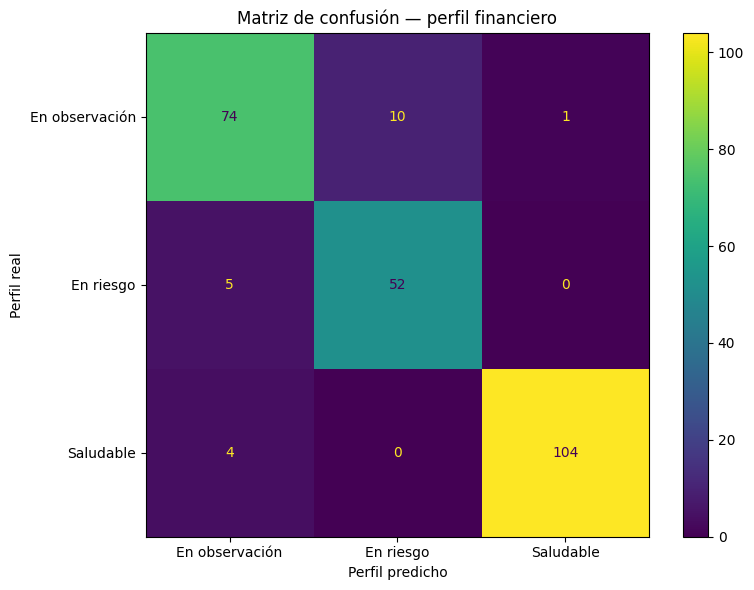

In [106]:
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_perfil_test,
    pred_perfil,
    ax=ax,
)

ax.set_title(
    "Matriz de confusión — perfil financiero"
)

ax.set_xlabel("Perfil predicho")
ax.set_ylabel("Perfil real")

plt.tight_layout()
plt.show()

### Interpretación del resultado

La evaluación hold-out muestra un desempeño muy sólido del modelo para la clasificación del perfil financiero. Se obtuvo un **Accuracy de 0.9200**, acompañado por un **F1 Macro de 0.9105** y un **F1 Weighted de 0.9206**, lo que indica un rendimiento elevado y equilibrado entre las distintas clases.

El modelo clasifica especialmente bien el perfil **Saludable**, alcanzando una precisión de **0.99**, un recall de **0.96** y un F1-score de **0.98**. Los perfiles **En observación** y **En riesgo** también presentan resultados satisfactorios, con valores de F1 superiores a **0.87**, lo que demuestra una buena capacidad de discriminación entre los distintos niveles de salud financiera.

Las diferencias entre las métricas de las tres clases son reducidas, lo que sugiere que el modelo no concentra su desempeño únicamente en la categoría mayoritaria. En conjunto, estos resultados indican que las variables financieras originales y los atributos agregados derivados del comportamiento transaccional proporcionan información suficiente para caracterizar adecuadamente el perfil financiero de los usuarios.

### Limitación de la evaluación hold-out

El conjunto de prueba está compuesto por **250 usuarios**, mientras que el entrenamiento utiliza **750 usuarios**. Aunque esta partición proporciona una estimación confiable del rendimiento del modelo, las métricas obtenidas siguen dependiendo de una única división del conjunto de datos.

Por este motivo, la evaluación hold-out se complementa en la siguiente sección con una validación cruzada estratificada, que utiliza múltiples particiones de los usuarios y permite obtener una estimación más robusta y estable del desempeño del clasificador.

## 19. Validación cruzada estratificada

Como complemento de la evaluación hold-out, se aplica una validación cruzada estratificada de cinco pliegues (5-Fold Stratified Cross Validation).

En cada iteración, el modelo se entrena utilizando una partición diferente del conjunto de usuarios y se evalúa sobre el pliegue restante, preservando la proporción de los perfiles financieros en todas las divisiones. Esta metodología proporciona una estimación más robusta y estable del rendimiento del clasificador, reduciendo la dependencia de una única partición de entrenamiento y prueba.

In [107]:
cv_perfil = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

resultados_cv_perfil = cross_validate(
    estimator=modelo_perfil,
    X=X_perfil,
    y=y_perfil,
    cv=cv_perfil,
    scoring={
        "accuracy": "accuracy",
        "f1_macro": "f1_macro",
        "f1_weighted": "f1_weighted",
    },
    return_train_score=False,
    n_jobs=None,
)

resumen_cv_perfil = pd.DataFrame({
    "metrica": [
        "accuracy",
        "f1_macro",
        "f1_weighted",
    ],
    "promedio": [
        resultados_cv_perfil["test_accuracy"].mean(),
        resultados_cv_perfil["test_f1_macro"].mean(),
        resultados_cv_perfil["test_f1_weighted"].mean(),
    ],
    "desvio_estandar": [
        resultados_cv_perfil["test_accuracy"].std(),
        resultados_cv_perfil["test_f1_macro"].std(),
        resultados_cv_perfil["test_f1_weighted"].std(),
    ],
})

display(
    resumen_cv_perfil.round(4)
)

,metrica,promedio,desvio_estandar
0,accuracy,0.9220,0.0172
1,f1_macro,0.9119,0.0168
2,f1_weighted,0.9220,0.0173


### Interpretación del resultado

La validación cruzada estratificada proporciona una estimación más robusta del rendimiento del modelo al evaluar su desempeño sobre cinco particiones diferentes del conjunto de datos. El promedio de las métricas resume el comportamiento esperado del clasificador, mientras que el desvío estándar permite analizar la estabilidad de los resultados entre los distintos pliegues.

Un desvío estándar reducido indica que el modelo mantiene un rendimiento consistente independientemente de la partición utilizada, lo que aporta mayor confianza en su capacidad de generalización sobre nuevos usuarios.

## 20. Interpretabilidad del modelo de perfil financiero

Con el objetivo de comprender el funcionamiento del clasificador, se analizan las variables con mayor influencia positiva en la predicción de cada perfil financiero.

Al utilizar una Regresión Logística multiclase, es posible inspeccionar directamente los coeficientes del modelo para identificar qué variables financieras y atributos derivados del comportamiento transaccional contribuyen con mayor intensidad a la clasificación de cada perfil. Este análisis aporta interpretabilidad y permite verificar que las decisiones del modelo se fundamentan en patrones consistentes con el dominio financiero.

In [108]:
modelo_perfil.fit(
    X_perfil,
    y_perfil,
)

preprocesador_perfil_entrenado = (
    modelo_perfil.named_steps[
        "preprocesamiento"
    ]
)

clasificador_perfil_entrenado = (
    modelo_perfil.named_steps[
        "clasificador"
    ]
)

nombres_features_perfil = (
    preprocesador_perfil_entrenado.get_feature_names_out()
)

coeficientes_perfil = (
    clasificador_perfil_entrenado.coef_
)

clases_perfil = (
    clasificador_perfil_entrenado.classes_
)

TOP_FEATURES = 8

filas_importancia_perfil = []

for indice_clase, clase in enumerate(clases_perfil):

    mejores_indices = np.argsort(
        coeficientes_perfil[indice_clase]
    )[-TOP_FEATURES:][::-1]

    for posicion, indice_feature in enumerate(
        mejores_indices,
        start=1,
    ):
        nombre_feature = (
            nombres_features_perfil[indice_feature]
            .replace("numericas__", "")
            .replace("categoricas__", "")
        )

        filas_importancia_perfil.append({
            "perfil": clase,
            "posicion": posicion,
            "feature": nombre_feature,
            "coeficiente": coeficientes_perfil[
                indice_clase,
                indice_feature,
            ],
        })

importancia_perfil = (
    pd.DataFrame(filas_importancia_perfil)
    .sort_values(
        ["perfil", "posicion"]
    )
    .reset_index(drop=True)
)

display(
    importancia_perfil.round({
        "coeficiente": 4,
    })
)

,perfil,posicion,feature,coeficiente
0,En observación,1,frecuencia_ahorro_Media,0.8998
1,En observación,2,ratio_deuda_ingreso_calculado,0.7653
2,En observación,3,frecuencia_ahorro_Baja,0.6485
3,En observación,4,porcentaje_gastos_ingreso,0.2892
4,En observación,5,gasto_mensual_promedio,0.2467
5,En observación,6,monto_maximo,0.2240
6,En observación,7,ahorro_mensual_estimado,0.1803
7,En observación,8,cantidad_recurrentes,0.1136
8,En riesgo,1,deuda_mensual,3.0632
9,En riesgo,2,nivel_endeudamiento,2.5473


### Interpretación del resultado

El análisis de los coeficientes muestra que el modelo fundamenta sus decisiones en variables financieras coherentes con la definición de cada perfil. En el perfil **En riesgo** predominan indicadores relacionados con el endeudamiento, como la **deuda mensual**, el **nivel de endeudamiento**, el **ratio gasto/ingreso** y el **porcentaje de gastos sobre los ingresos**, además de la ausencia de hábitos de ahorro (*frecuencia_ahorro = Nunca*). Estas variables reflejan un comportamiento financiero de mayor vulnerabilidad.

Para el perfil **Saludable**, las variables con mayor influencia están asociadas a una situación financiera equilibrada, destacándose el **ratio ahorro/ingreso**, el **ahorro mensual estimado** y una **frecuencia de ahorro alta**, lo que evidencia la importancia de la capacidad de ahorro en la clasificación realizada por el modelo.

Por su parte, el perfil **En observación** presenta un comportamiento intermedio, caracterizado principalmente por una **frecuencia de ahorro media**, un nivel moderado de endeudamiento y un porcentaje de gastos sobre los ingresos superior al observado en los usuarios clasificados como saludables, aunque sin alcanzar los valores característicos del perfil de mayor riesgo.

En conjunto, estos resultados indican que el modelo no basa sus decisiones en variables arbitrarias, sino en indicadores financieros consistentes con la lógica utilizada para construir los perfiles del conjunto de datos. La inspección de los coeficientes aporta transparencia al proceso de clasificación y facilita la interpretación del comportamiento del modelo.

# 21. Inferencia, recomendaciones y contrato JSON

Esta sección simula el comportamiento esperado del modelo en un entorno de producción. El backend podrá enviar los datos de una transacción o de un usuario y recibir una respuesta estructurada en formato JSON con predicciones, probabilidades y recomendaciones.

Para la clasificación de gastos, la entrada se transforma utilizando las mismas reglas de limpieza e ingeniería de atributos aplicadas durante el entrenamiento. De esta forma, se garantiza la consistencia entre los datos utilizados por el notebook y los que serán recibidos posteriormente por la API.

In [109]:
def preparar_transaccion_inferencia(
    descripcion: str,
    monto: float,
    fecha: str,
    medio_pago: str,
    recurrente: str,
) -> pd.DataFrame:
    if not descripcion or not descripcion.strip():
        raise ValueError(
            "La descripción no puede estar vacía."
        )

    if monto <= 0:
        raise ValueError(
            "El monto debe ser mayor que cero."
        )

    fecha_convertida = pd.Timestamp(fecha)
    descripcion_limpia = normalizar_texto(
        descripcion
    )

    return pd.DataFrame([{
        "descripcion_limpia": descripcion_limpia,
        "monto": float(monto),
        "mes": fecha_convertida.month,
        "dia_semana": fecha_convertida.dayofweek,
        "es_fin_de_semana": int(
            fecha_convertida.dayofweek in [5, 6]
        ),
        "longitud_descripcion": len(
            descripcion_limpia
        ),
        "cantidad_palabras": len(
            descripcion_limpia.split()
        ),
        "medio_pago": medio_pago,
        "recurrente": recurrente,
    }])


def predecir_categoria(
    descripcion: str,
    monto: float,
    fecha: str,
    medio_pago: str,
    recurrente: str,
) -> dict:
    entrada = preparar_transaccion_inferencia(
        descripcion=descripcion,
        monto=monto,
        fecha=fecha,
        medio_pago=medio_pago,
        recurrente=recurrente,
    )

    categoria_predicha = (
        modelo_categoria.predict(entrada)[0]
    )

    probabilidades = (
        modelo_categoria.predict_proba(entrada)[0]
    )

    clases = modelo_categoria.classes_

    probabilidades_por_categoria = {
        str(clase): round(
            float(probabilidad),
            4,
        )
        for clase, probabilidad in zip(
            clases,
            probabilidades,
        )
    }

    confianza = probabilidades_por_categoria[
        str(categoria_predicha)
    ]

    return {
        "tipo_transaccion": "GASTO",
        "categoria_predicha": str(
            categoria_predicha
        ),
        "confianza": confianza,
        "probabilidades": (
            probabilidades_por_categoria
        ),
    }

In [110]:
resultado_categoria = predecir_categoria(
    descripcion="Compra en verdulería",
    monto=42.50,
    fecha="2026-07-18",
    medio_pago="Tarjeta de débito",
    recurrente="No",
)

print(
    json.dumps(
        resultado_categoria,
        indent=4,
        ensure_ascii=False,
    )
)

{
    "tipo_transaccion": "GASTO",
    "categoria_predicha": "Alimentación",
    "confianza": 0.995,
    "probabilidades": {
        "Alimentación": 0.995,
        "Compras": 0.0017,
        "Educación": 0.0004,
        "Ocio": 0.0005,
        "Otros": 0.0008,
        "Salud": 0.0001,
        "Servicios": 0.0002,
        "Transporte": 0.0012,
        "Vivienda": 0.0002
    }
}


### Interpretación del contrato de salida

La función devuelve una respuesta estructurada en formato JSON, compatible con su integración en un servicio web. Además de la categoría predicha, se incluyen la confianza asociada a la predicción y la distribución de probabilidades para todas las categorías posibles.

Este formato permite que el backend consuma directamente el resultado generado por el modelo y lo exponga mediante una API REST. La información de confianza y las probabilidades también pueden utilizarse para implementar reglas de negocio, como solicitar la confirmación del usuario cuando la predicción presente un bajo nivel de certeza o registrar casos para su posterior análisis.

## 22. Casos de uso para clasificación de gastos

In [111]:
casos_transacciones = [
    {
        "descripcion": "Compra semanal en supermercado",
        "monto": 85.40,
        "fecha": "2026-07-16",
        "medio_pago": "Billetera virtual",
        "recurrente": "No",
    },
    {
        "descripcion": "Pago de plataforma de streaming",
        "monto": 14.99,
        "fecha": "2026-07-12",
        "medio_pago": "Débito automático",
        "recurrente": "Sí",
    },
    {
        "descripcion": "Consulta médica y medicamentos",
        "monto": 72.50,
        "fecha": "2026-07-15",
        "medio_pago": "Tarjeta de crédito",
        "recurrente": "No",
    },
]

resultados_casos = []

for caso in casos_transacciones:
    resultado = predecir_categoria(**caso)

    resultados_casos.append({
        **caso,
        **resultado,
    })

display(
    pd.DataFrame(resultados_casos)
)

,descripcion,monto,fecha,medio_pago,recurrente,tipo_transaccion,categoria_predicha,confianza,probabilidades
0,Compra semanal en supermercado,85.4000,2026-07-16,Billetera virtual,No,GASTO,Alimentación,0.7716,"{'Alimentación': 0.7716, 'Compras': 0.1801, 'E..."
1,Pago de plataforma de streaming,14.9900,2026-07-12,Débito automático,Sí,GASTO,Ocio,0.6683,"{'Alimentación': 0.0005, 'Compras': 0.1637, 'E..."
2,Consulta médica y medicamentos,72.5000,2026-07-15,Tarjeta de crédito,No,GASTO,Salud,0.9059,"{'Alimentación': 0.0005, 'Compras': 0.0482, 'E..."


### Interpretación de los casos de uso

Los tres ejemplos simulan transacciones que podrían ser enviadas por el backend al servicio de Ciencia de Datos. Para cada caso, el pipeline aplica la limpieza textual, genera las variables necesarias y devuelve una categoría predicha junto con su nivel de confianza y la distribución de probabilidades.

Esta prueba permite verificar que el modelo puede procesar múltiples transacciones con diferentes descripciones, montos, fechas y medios de pago utilizando el mismo contrato de entrada y salida definido para la integración con la API.

## 23. Análisis integral del usuario y generación de recomendaciones

Esta sección integra el modelo de perfil financiero con indicadores económicos, categorías principales de gasto y reglas de recomendación.

A partir del identificador de un usuario, se recuperan sus características financieras, se predice su perfil, se calculan sus principales categorías de gasto y se generan recomendaciones personalizadas. El resultado se devuelve mediante una estructura compatible con JSON para facilitar su consumo desde el backend.

In [112]:
def generar_recomendaciones(
    fila_usuario: pd.Series,
) -> list[str]:
    recomendaciones = []

    ratio_gasto = float(
        fila_usuario[
            "ratio_gasto_ingreso_calculado"
        ]
    )

    ratio_deuda = float(
        fila_usuario[
            "ratio_deuda_ingreso_calculado"
        ]
    )

    ratio_ahorro = float(
        fila_usuario[
            "ratio_ahorro_ingreso_calculado"
        ]
    )

    recurrentes = int(
        fila_usuario["cantidad_recurrentes"]
    )

    if ratio_gasto >= 0.80:
        recomendaciones.append(
            "Reducir los gastos mensuales y priorizar las categorías esenciales."
        )
    elif ratio_gasto >= 0.60:
        recomendaciones.append(
            "Revisar las categorías de mayor consumo para liberar capacidad de ahorro."
        )
    else:
        recomendaciones.append(
            "Mantener el nivel de gasto actual y revisar el presupuesto periódicamente."
        )

    if ratio_deuda >= 0.35:
        recomendaciones.append(
            "Priorizar la reducción de deuda antes de asumir nuevos compromisos financieros."
        )
    elif ratio_deuda >= 0.20:
        recomendaciones.append(
            "Evitar incrementar la deuda y planificar pagos anticipados cuando sea posible."
        )
    else:
        recomendaciones.append(
            "El nivel de endeudamiento se encuentra controlado."
        )

    if ratio_ahorro < 0.10:
        recomendaciones.append(
            "Definir un objetivo inicial de ahorro de al menos el 10% del ingreso mensual."
        )
    elif ratio_ahorro < 0.20:
        recomendaciones.append(
            "Incrementar gradualmente el porcentaje destinado al ahorro."
        )
    else:
        recomendaciones.append(
            "Mantener el hábito de ahorro y considerar la construcción de un fondo de emergencia."
        )

    if recurrentes >= 15:
        recomendaciones.append(
            "Auditar suscripciones y débitos automáticos para detectar cargos innecesarios."
        )

    return recomendaciones

In [113]:
def analizar_usuario(
    usuario_id: str,
) -> dict:
    coincidencias = dataset_perfiles[
        dataset_perfiles["usuario_id"]
        == usuario_id
    ]

    if coincidencias.empty:
        raise ValueError(
            f"No existe el usuario {usuario_id}."
        )

    fila = coincidencias.iloc[0]

    entrada_perfil = (
        fila[features_perfil]
        .to_frame()
        .T
    )

    perfil_predicho = modelo_perfil.predict(
        entrada_perfil
    )[0]

    probabilidades = modelo_perfil.predict_proba(
        entrada_perfil
    )[0]

    clases = modelo_perfil.classes_

    probabilidades_perfil = {
        str(clase): round(
            float(probabilidad),
            4,
        )
        for clase, probabilidad in zip(
            clases,
            probabilidades,
        )
    }

    confianza_perfil = probabilidades_perfil[
        str(perfil_predicho)
    ]

    # Se consideran únicamente los gastos
    gastos_usuario = transacciones_features[
        (
            transacciones_features["usuario_id"]
            == usuario_id
        )
        & (
            transacciones_features["tipo"]
            == "GASTO"
        )
    ].copy()

    categorias_principales = (
        gastos_usuario
        .groupby("categoria")["monto"]
        .sum()
        .sort_values(ascending=False)
        .head(3)
    )

    total_gastado = float(
        gastos_usuario["monto"].sum()
    )

    categorias_json = []

    for categoria, monto in categorias_principales.items():
        porcentaje = (
            float(monto) / total_gastado * 100
            if total_gastado > 0
            else 0.0
        )

        categorias_json.append({
            "categoria": str(categoria),
            "monto": round(
                float(monto),
                2,
            ),
            "porcentaje": round(
                porcentaje,
                2,
            ),
        })

    return {
        "usuario_id": str(usuario_id),
        "perfil_financiero": str(
            perfil_predicho
        ),
        "confianza_perfil": confianza_perfil,
        "probabilidades_perfil": (
            probabilidades_perfil
        ),
        "metricas": {
            "ingreso_mensual": round(
                float(
                    fila["ingreso_mensual"]
                ),
                2,
            ),
            "gasto_mensual_promedio": round(
                float(
                    fila[
                        "gasto_mensual_promedio"
                    ]
                ),
                2,
            ),
            "deuda_mensual": round(
                float(
                    fila["deuda_mensual"]
                ),
                2,
            ),
            "ahorro_mensual_estimado": round(
                float(
                    fila[
                        "ahorro_mensual_estimado"
                    ]
                ),
                2,
            ),
            "ratio_gasto_ingreso": round(
                float(
                    fila[
                        "ratio_gasto_ingreso_calculado"
                    ]
                ),
                4,
            ),
            "ratio_deuda_ingreso": round(
                float(
                    fila[
                        "ratio_deuda_ingreso_calculado"
                    ]
                ),
                4,
            ),
            "ratio_ahorro_ingreso": round(
                float(
                    fila[
                        "ratio_ahorro_ingreso_calculado"
                    ]
                ),
                4,
            ),
        },
        "total_gastado_periodo": round(
            total_gastado,
            2,
        ),
        "categorias_principales_gasto": (
            categorias_json
        ),
        "recomendaciones": (
            generar_recomendaciones(fila)
        ),
        "modelo_version": "6.0.0",
    }

In [114]:
usuario_ejemplo = dataset_perfiles[
    "usuario_id"
].iloc[0]

resultado_usuario = analizar_usuario(
    usuario_ejemplo
)

print(
    json.dumps(
        resultado_usuario,
        indent=4,
        ensure_ascii=False,
    )
)

{
    "usuario_id": "USR0001",
    "perfil_financiero": "Saludable",
    "confianza_perfil": 0.9785,
    "probabilidades_perfil": {
        "En observación": 0.0215,
        "En riesgo": 0.0,
        "Saludable": 0.9785
    },
    "metricas": {
        "ingreso_mensual": 4625.5,
        "gasto_mensual_promedio": 1809.44,
        "deuda_mensual": 832.9,
        "ahorro_mensual_estimado": 1983.16,
        "ratio_gasto_ingreso": 0.3912,
        "ratio_deuda_ingreso": 0.1801,
        "ratio_ahorro_ingreso": 0.4287
    },
    "total_gastado_periodo": 21713.28,
    "categorias_principales_gasto": [
        {
            "categoria": "Compras",
            "monto": 4734.18,
            "porcentaje": 21.8
        },
        {
            "categoria": "Educación",
            "monto": 3201.74,
            "porcentaje": 14.75
        },
        {
            "categoria": "Salud",
            "monto": 3029.8,
            "porcentaje": 13.95
        }
    ],
    "recomendaciones": [
        "Mante

### Interpretación del resultado

La función integra la predicción del perfil financiero con indicadores económicos, categorías principales de gasto y recomendaciones generadas mediante reglas de negocio.

El contrato resultante puede ser consumido directamente por el backend para construir paneles financieros personalizados, mostrar el estado financiero del usuario y ofrecer recomendaciones adaptadas a su situación económica.

Las categorías principales se calculan exclusivamente a partir de las transacciones de gasto, mientras que la predicción del perfil financiero considera conjuntamente ingresos, gastos, nivel de endeudamiento y capacidad de ahorro. Esta integración demuestra cómo los modelos desarrollados pueden incorporarse dentro de una arquitectura orientada a servicios y utilizarse como base para una aplicación de educación y gestión financiera.

## 24. Tres ejemplos completos de análisis de usuario

In [115]:
usuarios_demo = [
    "USR0001",
    "USR0004",
    "USR0008",
]

analisis_demo = [
    analizar_usuario(usuario_id)
    for usuario_id in usuarios_demo
]

for resultado in analisis_demo:
    print(json.dumps(
        resultado,
        ensure_ascii=False,
        indent=2,
    ))
    print("-" * 80)

{
  "usuario_id": "USR0001",
  "perfil_financiero": "Saludable",
  "confianza_perfil": 0.9785,
  "probabilidades_perfil": {
    "En observación": 0.0215,
    "En riesgo": 0.0,
    "Saludable": 0.9785
  },
  "metricas": {
    "ingreso_mensual": 4625.5,
    "gasto_mensual_promedio": 1809.44,
    "deuda_mensual": 832.9,
    "ahorro_mensual_estimado": 1983.16,
    "ratio_gasto_ingreso": 0.3912,
    "ratio_deuda_ingreso": 0.1801,
    "ratio_ahorro_ingreso": 0.4287
  },
  "total_gastado_periodo": 21713.28,
  "categorias_principales_gasto": [
    {
      "categoria": "Compras",
      "monto": 4734.18,
      "porcentaje": 21.8
    },
    {
      "categoria": "Educación",
      "monto": 3201.74,
      "porcentaje": 14.75
    },
    {
      "categoria": "Salud",
      "monto": 3029.8,
      "porcentaje": 13.95
    }
  ],
  "recomendaciones": [
    "Mantener el nivel de gasto actual y revisar el presupuesto periódicamente.",
    "El nivel de endeudamiento se encuentra controlado.",
    "Mantener 

### Interpretación

Los ejemplos anteriores muestran el funcionamiento del servicio de análisis financiero a nivel de usuario. Para cada identificador se integran las métricas financieras, la predicción del perfil, las categorías principales de gasto y las recomendaciones generadas mediante reglas de negocio.

Este formato representa la respuesta que consumiría el backend de FinSightAI para construir paneles personalizados y ofrecer recomendaciones financieras adaptadas a cada usuario.

# 25. Serialización y verificación de artefactos

Se guardan los modelos completos, incluyendo preprocesamiento y clasificador, junto con metadatos, métricas y ejemplos JSON.

In [116]:
print("Serializando modelos...")

RUTA_MODELO_CATEGORIA = MODELS_DIR / "clasificador_gastos.joblib"
RUTA_MODELO_PERFIL = MODELS_DIR / "clasificador_perfil.joblib"
RUTA_METADATA = ARTIFACTS_DIR / "metadata_modelos.json"
RUTA_METRICAS = ARTIFACTS_DIR / "metricas_modelos.csv"
RUTA_EJEMPLOS_JSON = ARTIFACTS_DIR / "ejemplos_respuesta_backend.json"

# ============================
# Modelos
# ============================

joblib.dump(modelo_categoria, RUTA_MODELO_CATEGORIA)
joblib.dump(modelo_perfil, RUTA_MODELO_PERFIL)

# ============================
# Métricas
# ============================

metricas_finales = pd.DataFrame([
    {
        "modelo": "Clasificación de gastos (Hold-Out)",
        "accuracy": metricas_categoria_holdout["accuracy"],
        "f1_macro": metricas_categoria_holdout["f1_macro"],
        "f1_weighted": metricas_categoria_holdout["f1_weighted"],
    },
    {
        "modelo": "Clasificación de gastos (CV agrupada)",
        "accuracy": resultados_cv_categoria["test_accuracy"].mean(),
        "f1_macro": resultados_cv_categoria["test_f1_macro"].mean(),
        "f1_weighted": resultados_cv_categoria["test_f1_weighted"].mean(),
    },
    {
        "modelo": "Perfil financiero (Hold-Out)",
        "accuracy": metricas_perfil_holdout["accuracy"],
        "f1_macro": metricas_perfil_holdout["f1_macro"],
        "f1_weighted": metricas_perfil_holdout["f1_weighted"],
    },
    {
        "modelo": "Perfil financiero (Validación Cruzada)",
        "accuracy": resultados_cv_perfil["test_accuracy"].mean(),
        "f1_macro": resultados_cv_perfil["test_f1_macro"].mean(),
        "f1_weighted": resultados_cv_perfil["test_f1_weighted"].mean(),
    },
])

metricas_finales.to_csv(
    RUTA_METRICAS,
    index=False,
)

# ============================
# Metadata
# ============================

metadata = {
    "version": "6.0.0",
    "random_state": RANDOM_STATE,
    "modelo_categoria": {
        "archivo": str(RUTA_MODELO_CATEGORIA),
        "features": features_categoria,
        "clases": list(modelo_categoria.classes_),
    },
    "modelo_perfil": {
        "archivo": str(RUTA_MODELO_PERFIL),
        "features": features_perfil,
        "clases": list(modelo_perfil.classes_),
    },
    "contrato_usuario_id": "Formato USRXXXX",
    "nota": (
        "Los modelos fueron entrenados con datos sintéticos. "
        "Antes de un entorno productivo deberán reentrenarse "
        "y validarse utilizando datos reales."
    ),
}

with open(RUTA_METADATA, "w", encoding="utf-8") as f:
    json.dump(
        metadata,
        f,
        ensure_ascii=False,
        indent=2,
    )

# ============================
# Ejemplos JSON
# ============================

with open(
    RUTA_EJEMPLOS_JSON,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        analisis_demo,
        f,
        ensure_ascii=False,
        indent=2,
    )

# ============================
# Resumen
# ============================

display(metricas_finales.round(4))

print("\nArtefactos generados:\n")

print(RUTA_MODELO_CATEGORIA)
print(RUTA_MODELO_PERFIL)
print(RUTA_METADATA)
print(RUTA_METRICAS)
print(RUTA_EJEMPLOS_JSON)

Serializando modelos...


,modelo,accuracy,f1_macro,f1_weighted
0,Clasificación de gastos (Hold-Out),1.0000,1.0000,1.0000
1,Clasificación de gastos (CV agrupada),0.3618,0.2739,0.3324
2,Perfil financiero (Hold-Out),0.9200,0.9105,0.9206
3,Perfil financiero (Validación Cruzada),0.9220,0.9119,0.9220



Artefactos generados:

artefactos_financeai_v3/modelos/clasificador_gastos.joblib
artefactos_financeai_v3/modelos/clasificador_perfil.joblib
artefactos_financeai_v3/metadata_modelos.json
artefactos_financeai_v3/metricas_modelos.csv
artefactos_financeai_v3/ejemplos_respuesta_backend.json


## 26. Prueba de recarga

La serialización se considera completa únicamente si los modelos pueden cargarse nuevamente desde disco y producir predicciones válidas.

En esta sección se verifican los artefactos generados mediante `joblib`, se cargan ambos modelos y se ejecutan predicciones de prueba utilizando el mismo contrato de entrada definido para la inferencia.

In [117]:
# ============================
# Recarga de modelos
# ============================

modelo_categoria_recargado = joblib.load(
    RUTA_MODELO_CATEGORIA
)

modelo_perfil_recargado = joblib.load(
    RUTA_MODELO_PERFIL
)

print("Modelos cargados correctamente.")


# ============================
# Prueba del clasificador de gastos
# ============================

transaccion_prueba = preparar_transaccion_inferencia(
    descripcion="Compra en supermercado",
    monto=18500,
    fecha="2026-07-17",
    medio_pago="Tarjeta de débito",
    recurrente="No",
)

categoria_recargada = (
    modelo_categoria_recargado
    .predict(transaccion_prueba)[0]
)

probabilidades_categoria = (
    modelo_categoria_recargado
    .predict_proba(transaccion_prueba)[0]
)

resultado_categoria_recarga = {
    "categoria_predicha": categoria_recargada,
    "confianza": float(
        probabilidades_categoria.max()
    ),
}

print("\nClasificador de gastos:")
print(json.dumps(
    resultado_categoria_recarga,
    ensure_ascii=False,
    indent=2,
))


# ============================
# Prueba del modelo de perfil
# ============================

usuario_prueba_id = "USR0001"

fila_usuario_prueba = dataset_perfiles.loc[
    dataset_perfiles["usuario_id"] == usuario_prueba_id,
    features_perfil,
].copy()

if fila_usuario_prueba.empty:
    raise ValueError(
        f"No se encontró el usuario {usuario_prueba_id}."
    )

perfil_recargado = (
    modelo_perfil_recargado
    .predict(fila_usuario_prueba)[0]
)

probabilidades_perfil = (
    modelo_perfil_recargado
    .predict_proba(fila_usuario_prueba)[0]
)

resultado_perfil_recarga = {
    "usuario_id": usuario_prueba_id,
    "perfil_predicho": perfil_recargado,
    "confianza": float(
        probabilidades_perfil.max()
    ),
}

print("\nClasificador de perfil financiero:")
print(json.dumps(
    resultado_perfil_recarga,
    ensure_ascii=False,
    indent=2,
))

Modelos cargados correctamente.

Clasificador de gastos:
{
  "categoria_predicha": "Vivienda",
  "confianza": 0.9999999927758203
}

Clasificador de perfil financiero:
{
  "usuario_id": "USR0001",
  "perfil_predicho": "Saludable",
  "confianza": 0.9784940779887973
}


In [118]:
assert categoria_recargada is not None
assert perfil_recargado is not None

print(
    "\n✅ Verificación completada: "
    "los modelos fueron recargados y generaron predicciones."
)


✅ Verificación completada: los modelos fueron recargados y generaron predicciones.


### Interpretación

La prueba de recarga confirma que los modelos serializados pueden recuperarse correctamente desde disco y utilizarse para realizar nuevas predicciones sin necesidad de repetir el entrenamiento.

Esta verificación garantiza que los artefactos generados contienen tanto el preprocesamiento como el clasificador entrenado, lo que permite reutilizarlos posteriormente desde el microservicio desarrollado con FastAPI.

# 27. Conclusiones

El presente notebook cumple de forma integral los requerimientos de Ciencia de Datos establecidos para el proyecto FinSightAI, desarrollando un pipeline completo que abarca:

- exploración y limpieza de datos (EDA);
- procesamiento de variables financieras y textuales;
- ingeniería de atributos;
- clasificación automática de gastos;
- análisis del perfil financiero de los usuarios;
- entrenamiento y evaluación de modelos de aprendizaje automático;
- cálculo de métricas de rendimiento;
- validación cruzada;
- evaluación agrupada para reducir la repetición de descripciones entre entrenamiento y validación;
- interpretabilidad de los modelos;
- serialización y verificación de los artefactos generados;
- prueba de recarga de modelos;
- generación automática de recomendaciones financieras;
- cálculo de score financiero y nivel de riesgo;
- generación de fortalezas, oportunidades de mejora y explicaciones del resultado obtenido;
- ejemplos completos de inferencia;
- generación de respuestas estructuradas en formato JSON para su integración con servicios externos.

Como parte del MVP, los modelos entrenados fueron integrados en un microservicio desarrollado con FastAPI. Este servicio expone endpoints para clasificar transacciones y analizar perfiles financieros, devolviendo respuestas estructuradas que pueden ser consumidas por el backend desarrollado en Spring Boot y posteriormente visualizadas desde el frontend de la aplicación.

## Limitaciones

El presente trabajo posee las siguientes limitaciones:

- Los datos utilizados son completamente sintéticos y fueron generados para simular distintos comportamientos financieros.
- El dataset está compuesto por aproximadamente 1.000 usuarios y más de 60.000 transacciones sintéticas, proporcionando una base adecuada para el desarrollo y validación del MVP. No obstante, será necesario entrenar y evaluar los modelos con datos reales para validar su capacidad de generalización.
- El clasificador de gastos deberá reentrenarse utilizando transacciones reales con un vocabulario más amplio, diverso y representativo de distintos contextos financieros.
- Las recomendaciones, el score financiero y el nivel de riesgo se basan en reglas de negocio explicables diseñadas para el MVP y deberían ser revisadas por especialistas del dominio financiero antes de utilizarse en un entorno productivo.
- Las métricas obtenidas validan el correcto funcionamiento técnico del pipeline implementado, aunque su desempeño deberá confirmarse posteriormente mediante conjuntos de datos externos e independientes.
- El score financiero desarrollado constituye un indicador propio del proyecto y no representa una calificación crediticia oficial ni reemplaza el asesoramiento financiero profesional.